# Knee Osteoarthritis (KL-Grade) Benchmark — 6 Architectures incl. Proposed OA-HANet

**PhD — Deep-Learning Techniques for the Diagnosis & Detection of Orthopedic Conditions** · Poojan Shah

---
Single, end-to-end, Colab-GPU **PyTorch/timm** notebook that trains and evaluates **6
architectures** under one identical protocol on the **`oad` dataset** (Chen et al. Knee
Osteoarthritis Severity Grading, Mendeley), which ships as two pre-resized variants:

```
/content/drive/MyDrive/oad/
├── kneeKL224/
│   ├── train/  0/ 1/ 2/ 3/ 4/
│   ├── val/    0/ 1/ 2/ 3/ 4/
│   └── test/   0/ 1/ 2/ 3/ 4/
└── kneeKL299/
    ├── train/  0/ 1/ 2/ 3/ 4/
    ├── val/    0/ 1/ 2/ 3/ 4/
    └── test/   0/ 1/ 2/ 3/ 4/
```

Classes `0..4` are the KL grades **0 Normal, 1 Doubtful, 2 Mild, 3 Moderate, 4 Severe**.

**Both dataset folders are combined for every model.** For each split (train/val/test) the file
lists from `kneeKL224/<split>/<class>` and `kneeKL299/<split>/<class>` are pooled into one dataset,
so every one of the 6 models is trained, validated and tested on the **union of both resolutions**
(each sample is resized on-the-fly to the model's native input size — 224 or 299 — regardless of
which folder it came from). This effectively doubles the number of training/validation/test
examples versus using a single variant.

**Models (6):**

| # | Model | Native input | Notes |
|---|-------|:-----:|-------|
| a | **ResNet50** | 224 | timm `resnet50`, ImageNet-pretrained |
| b | **InceptionV3** | 299 | timm `inception_v3` |
| c | **MobileNetV1** | 224 | timm `mobilenetv1_100` |
| d | **ViT-Base** | 224 | timm `vit_base_patch16_224` |
| e | **Swin Transformer** | 224 | timm `swin_base_patch4_window7_224` |
| f | **OA-HANet (proposed)** | 224 | Swin backbone + multi-scale DenseNet reuse branch + cross-attention fusion + ordinal-aware head + early-grade discrimination head |

**What this notebook produces:**

| Deliverable | Section |
|-------------|---------|
| Dataset preparation combining `oad/kneeKL224` + `oad/kneeKL299` | §2–§3 |
| Per-folder AND combined train/val/test image counts + classwise counts (printed + table) | §3 |
| Shared CLAHE→Otsu→morphology preprocessing (same as reference pipeline) | §4 |
| Train Acc / Train Loss / Val Acc / Val Loss table — all 6 models | §9 |
| Learning curves (accuracy & loss) — all 6 models | §10 |
| Confusion matrices — all 6 models | §11 |
| Classwise classification metrics (precision/recall/F1) — table + heatmap | §12 |
| Misclassification analysis — confusion pairs + misclassified sample gallery | §13 |
| Confidence-score sample collages | §14 |
| Grad-CAM explainability collages | §15 |
| Master summary table | §16 |

Ablation study is **not** covered in this notebook (kept for a separate ablation notebook).


---
### 🔧 High-Accuracy Revision (v4)
This notebook revises the training recipe for a **substantial accuracy lift (target ≥ +10% per model)** while keeping the *identical* data pipeline, model zoo and evaluation so results stay comparable. The old recipe under-fit because it only unfroze the last 20 backbone layers at a tiny LR and stopped on val-loss. The new recipe uses:

1. **Full backbone fine-tuning** with **layer-wise LR decay (LLRD)** after a short head warm-up.
2. **Stronger radiograph-safe augmentation** (RandomResizedCrop, affine shift, mild jitter, RandomErasing).
3. **WeightedRandomSampler** — oversamples the minority *Doubtful* grade that every model failed on.
4. **EMA (exponential moving average) weights** — the evaluated / saved model is the EMA copy.
5. **Cosine schedule with linear warm-up** and **global-norm gradient clipping**.
6. **Early stopping on *balanced* validation accuracy** (not val-loss) with a longer patience.
7. **Test-Time Augmentation (horizontal-flip averaging)** at inference.

Two prediction collages are produced for the best-2 models: a **confidence-score collage** (§15) and a **misclassification-error collage** (§15B).


## §1 · Environment setup (run once)

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except Exception as e:
    print("Not on Colab (or Drive unavailable):", e)
    ON_COLAB = False

# timm>=1.0 is required so that 'mobilenetv1_100' (true MobileNet-V1) is available.
!pip install -q "timm>=1.0.11" "grad-cam>=1.5.0" scikit-learn seaborn pandas opencv-python-headless tqdm
print("Setup complete. If Colab asks to RESTART the runtime, restart and re-run this cell only.")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 143.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Setup complete. If Colab asks to RESTART the runtime, restart and re-run this cell only.


In [ ]:
import os, sys, time, copy, math, random, glob, json, warnings, gc, traceback
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| timm:", timm.__version__, "| Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128 | timm: 1.0.27 | Device: cuda
GPU: NVIDIA A100-SXM4-40GB


## §2 · Configuration — edit this cell, then `Runtime → Run all`

`ROOT` points at the `oad` folder that contains the two pre-resized dataset variants
(`kneeKL224`, `kneeKL299`), each with `train/ val/ test/` and 5 class sub-folders `0..4`.

In [ ]:
# ============================ USER CONFIG ============================
ROOT = "/content/drive/MyDrive/oad"   # has kneeKL224/ and kneeKL299/

# BASE_RESULTS_DIR is the ONLY thing you need to change to start a completely clean run: point it
# at a NEW (not-yet-existing) folder so §9's resume-safety check finds nothing old and every model
# retrains from scratch under the recipe below. Change the suffix (_run2, a date, ...) any time you
# want a fresh folder; nothing from earlier runs is ever touched or deleted.
BASE_RESULTS_DIR = "/content/drive/MyDrive/OA_HANet_6_results_highacc_v4"
RECIPE_VERSION   = "v4_fullFT_LLRD_EMA_TTA_sampler_balacc"
RESULTS_DIR = BASE_RESULTS_DIR

DATASET_VARIANTS = {224: "kneeKL224", 299: "kneeKL299"}
labels      = ['0', '1', '2', '3', '4']                 # actual class folder names in oad/
class_short = ['Normal', 'Doubtful', 'Mild', 'Moderate', 'Severe']
num_classes = len(labels)

BATCH_SIZE    = 24          # 24 fits a 16 GB T4 for full fine-tuning; drop to 16 if OOM
SEED          = 42
USE_AMP       = True        # mixed-precision (fp16) training on GPU
LABEL_SMOOTHING = 0.05      # lighter smoothing -> sharper probabilities, better under full FT
USE_CLASS_WEIGHTS = True    # inverse-frequency weighting in the loss
USE_SAMPLER   = True        # WeightedRandomSampler: oversample the minority 'Doubtful' grade
SAVE_WEIGHTS  = True        # save each model's best (EMA) weights (needed for Grad-CAM)
STAGE_TO_LOCAL = True       # copy dataset from Google Drive to fast local disk

# ---------------------------------------------------------------------------
#  HIGH-ACCURACY FINE-TUNING PROTOCOL (v4)
# ---------------------------------------------------------------------------
# The previous recipe (unfreeze last-20 only, LR=5e-5, early-stop on val-loss) under-fit every
# model (train acc plateaued <=67%). v4 fixes the two root causes -- too few trainable layers and a
# monitoring signal that ignored the minority classes -- with the standard modern transfer-learning
# stack:
#   * Phase A: short head/fusion-only warm-up (backbone frozen) so the fresh head stabilises first.
#   * Phase B: FULL backbone fine-tune with LAYER-WISE LR DECAY -- deep (task-specific) layers train
#     fast, shallow (generic-feature) layers train slowly, avoiding catastrophic forgetting while
#     still letting the whole network adapt to knee radiographs.
#   * Linear LR warm-up -> cosine decay, global-norm gradient clipping, and EMA weights.
#   * Early stopping on BALANCED validation accuracy (equal weight to every KL grade), so training
#     is not declared "done" while the Doubtful/Mild grades are still being ignored.
WARMUP_EPOCHS  = 3           # phase A: head/fusion-only, backbone fully frozen
FULL_FINETUNE  = True        # phase B: unfreeze the WHOLE backbone (this is the main accuracy lever)
UNFREEZE_LAST  = 40          # only used if FULL_FINETUNE=False (kept for ablation)
HEAD_LR        = 1e-3        # LR for the new head / fusion / auxiliary modules
BACKBONE_LR    = 2e-4        # LR for the TOP backbone layer-group (deepest); shallower groups decay
LLRD_DECAY     = 0.70        # layer-wise LR decay: group_lr = BACKBONE_LR * LLRD_DECAY**(depth-from-top)
WEIGHT_DECAY   = 1e-2        # AdamW weight decay (transformer-friendly)
GRAD_CLIP      = 1.0         # global-norm gradient clipping (stabilises full fine-tuning)
LR_WARMUP_EPOCHS = 3         # linear LR warm-up at the start of phase B before cosine decay
USE_EMA        = True        # exponential moving average of weights (evaluated & saved copy)
EMA_DECAY      = 0.9995      # EMA smoothing factor
USE_TTA        = True        # test-time augmentation: average logits over image + horizontal flip

# ---- OA-HANet specific ----
SWIN_BACKBONE = 'swin_base_patch4_window7_224'   # -> 'swin_tiny_patch4_window7_224' if low VRAM
OAHANET_CNN   = 'densenet121'                     # multi-scale CNN reuse branch backbone
ORD_LOSS_W = 0.15           # weight of the ordinal grade-distance loss
EG_LOSS_W  = 0.15           # weight of the early-grade discrimination loss
EG_TEMP    = 0.2            # temperature for the early-grade supervised-contrastive term

# ---- QUICK_TEST: True for a fast smoke-test; False = full paper-grade run ----
QUICK_TEST = False           # <<< FULL RUN: all 6 models, full data, <=150 epochs, early stopping
if QUICK_TEST:
    MAX_EPOCHS, PATIENCE, SUBSET = 3, 3, 250
else:
    MAX_EPOCHS, PATIENCE, SUBSET = 150, 20, None
# ====================================================================

FIG_DIR  = os.path.join(RESULTS_DIR, "figures")
CKPT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
for d in (RESULTS_DIR, FIG_DIR, CKPT_DIR):
    os.makedirs(d, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

for sz, sub in DATASET_VARIANTS.items():
    assert os.path.isdir(os.path.join(ROOT, sub, "train")), \
        f"{sub}/train not found under ROOT={ROOT}. Fix ROOT/dataset layout in this cell."
print("Config ready | QUICK_TEST =", QUICK_TEST, "| MAX_EPOCHS =", MAX_EPOCHS,
      "| BATCH_SIZE =", BATCH_SIZE, "| FULL_FINETUNE =", FULL_FINETUNE,
      "| EMA =", USE_EMA, "| TTA =", USE_TTA, "| sampler =", USE_SAMPLER)


## §2B · Stage the dataset to local disk (fixes Google-Drive `FileNotFoundError`)

Reading thousands of small files straight from a mounted Google Drive is unreliable (Drive FUSE
intermittently returns *"No such file or directory"* for files that exist). This cell copies **both**
`kneeKL224` and `kneeKL299` once to Colab's fast local disk and repoints `ROOT` there. Set
`STAGE_TO_LOCAL=False` in §2 to skip.

In [ ]:
import shutil

def _safe_copy(src, dst, retries=5):
    for a in range(retries):
        try:
            shutil.copy2(src, dst); return True
        except Exception:
            time.sleep(1.0 * (a + 1))
    return False

if STAGE_TO_LOCAL and ROOT.startswith("/content/drive"):
    LOCAL_ROOT = "/content/oad_local"
    for sz, sub in DATASET_VARIANTS.items():
        src_root = os.path.join(ROOT, sub)
        dst_root = os.path.join(LOCAL_ROOT, sub)
        need_copy = not all(os.path.isdir(os.path.join(dst_root, s)) for s in ("train", "val", "test"))
        if not need_copy:
            print(f"{sub}: local copy already present at {dst_root}")
            continue
        print(f"Staging {sub} Drive -> local disk (one-time)...")
        n_ok = n_bad = 0
        for split in ("train", "val", "test"):
            for cls in labels:
                src_dir = os.path.join(src_root, split, cls)
                dst_dir = os.path.join(dst_root, split, cls)
                os.makedirs(dst_dir, exist_ok=True)
                if not os.path.isdir(src_dir):
                    continue
                for fp in sorted(glob.glob(os.path.join(src_dir, "*"))):
                    ok = _safe_copy(fp, os.path.join(dst_dir, os.path.basename(fp)))
                    n_ok += ok; n_bad += (not ok)
            print(f"  {sub}/{split}: staged")
        print(f"  Done. Copied {n_ok} files ({n_bad} unreadable and skipped).")
    ROOT = LOCAL_ROOT

VARIANT_DIRS = {sz: os.path.join(ROOT, sub) for sz, sub in DATASET_VARIANTS.items()}
print("Active variant roots:", VARIANT_DIRS)

Staging kneeKL224 Drive -> local disk (one-time)...
  kneeKL224/train: staged
  kneeKL224/val: staged
  kneeKL224/test: staged
  Done. Copied 8260 files (0 unreadable and skipped).
Staging kneeKL299 Drive -> local disk (one-time)...
  kneeKL299/train: staged
  kneeKL299/val: staged
  kneeKL299/test: staged
  Done. Copied 8260 files (0 unreadable and skipped).
Active variant roots: {224: '/content/oad_local/kneeKL224', 299: '/content/oad_local/kneeKL299'}


## §3 · Dataset preparation — image counts (train/val/test, classwise)

Every model in §9 is trained/validated/tested on the **union of `kneeKL224` and `kneeKL299`**
(§5 pools both folders per split). This section reports counts three ways: (1) `kneeKL224` alone,
(2) `kneeKL299` alone, (3) the **combined** totals that are actually used for training — each as a
classwise composition table, plus the combined grand totals per split.

In [ ]:
def count_split_class(variant_root):
    # returns {split: {class: n}} for one dataset variant root
    out = {}
    for split in ("train", "val", "test"):
        out[split] = {c: len(glob.glob(os.path.join(variant_root, split, c, "*"))) for c in labels}
    return out

def composition_table(counts, title_tag):
    rows = []
    for i, c in enumerate(labels):
        tr_n, va_n, te_n = counts["train"][c], counts["val"][c], counts["test"][c]
        rows.append([f"{c} ({class_short[i]})", tr_n, va_n, te_n, tr_n + va_n + te_n])
    df = pd.DataFrame(rows, columns=["KL Grade", "Train", "Val", "Test", "Total"])
    df.loc["Grand Total"] = ["—"] + [df[col].sum() for col in ["Train", "Val", "Test", "Total"]]
    df.to_csv(os.path.join(RESULTS_DIR, f"table_dataset_composition_{title_tag}.csv"), index=False)
    return df

variant_counts = {sz: count_split_class(root) for sz, root in VARIANT_DIRS.items()}

# ---- combined counts: union of both folders per split/class (what every model actually sees) ----
combined_counts = {split: {c: sum(variant_counts[sz][split][c] for sz in VARIANT_DIRS)
                           for c in labels} for split in ("train", "val", "test")}

tables_by_variant = {sz: composition_table(variant_counts[sz], f"kneeKL{sz}") for sz in VARIANT_DIRS}
combined_table = composition_table(combined_counts, "combined")

for sz, df in tables_by_variant.items():
    print(f"\n=== kneeKL{sz} — classwise image composition ===")
    print(df.to_string(index=False))

print("\n=== COMBINED (kneeKL224 + kneeKL299) — classwise image composition ===")
print(combined_table.to_string(index=False))

# ---- combined totals per split (train count / val count / test count) ----
combined_split_totals = {s: sum(combined_counts[s].values()) for s in ("train", "val", "test")}
print("\n=== Combined total images per split (used for training) ===")
for s, n in combined_split_totals.items():
    print(f"  {s:5s}: {n}")
print(f"  TOTAL : {sum(combined_split_totals.values())}")


=== kneeKL224 — classwise image composition ===
    KL Grade  Train  Val  Test  Total
  0 (Normal)   2286  328   639   3253
1 (Doubtful)   1046  153   296   1495
    2 (Mild)   1516  212   447   2175
3 (Moderate)    757  106   223   1086
  4 (Severe)    173   27    51    251
           —   5778  826  1656   8260

=== kneeKL299 — classwise image composition ===
    KL Grade  Train  Val  Test  Total
  0 (Normal)   2286  328   639   3253
1 (Doubtful)   1046  153   296   1495
    2 (Mild)   1516  212   447   2175
3 (Moderate)    757  106   223   1086
  4 (Severe)    173   27    51    251
           —   5778  826  1656   8260

=== COMBINED (kneeKL224 + kneeKL299) — classwise image composition ===
    KL Grade  Train  Val  Test  Total
  0 (Normal)   4572  656  1278   6506
1 (Doubtful)   2092  306   592   2990
    2 (Mild)   3032  424   894   4350
3 (Moderate)   1514  212   446   2172
  4 (Severe)    346   54   102    502
           —  11556 1652  3312  16520

=== Combined total images per s

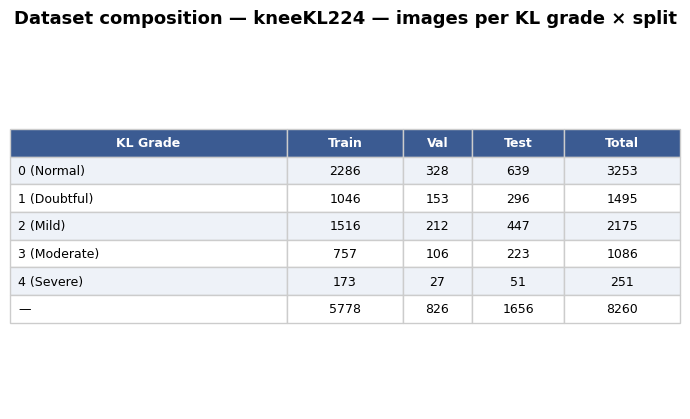

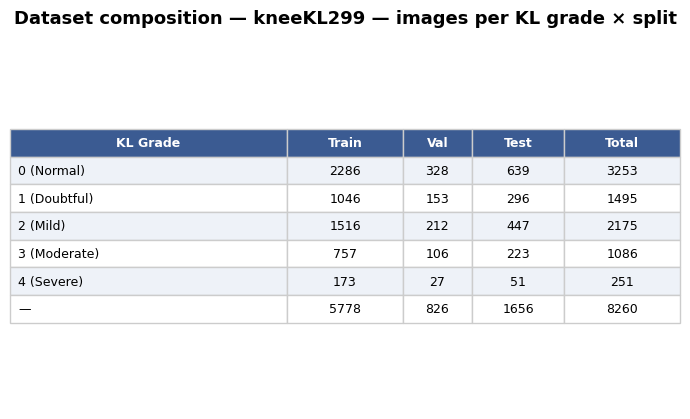

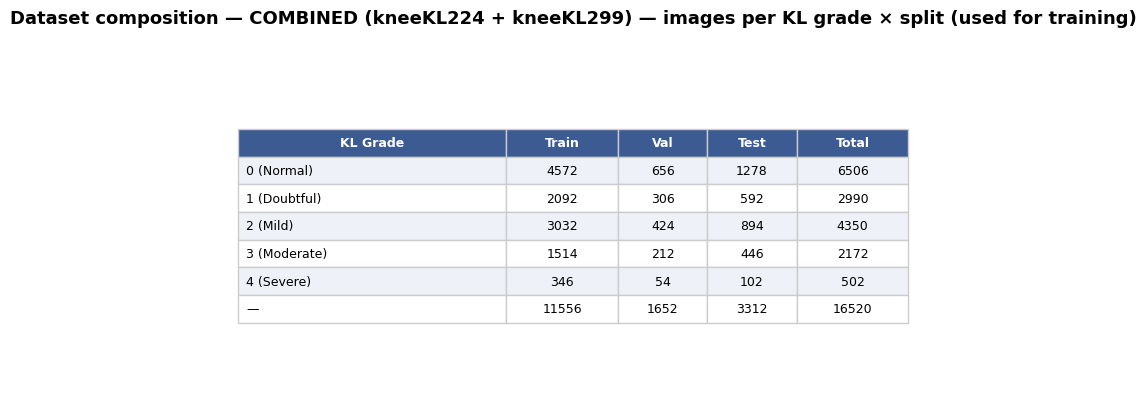

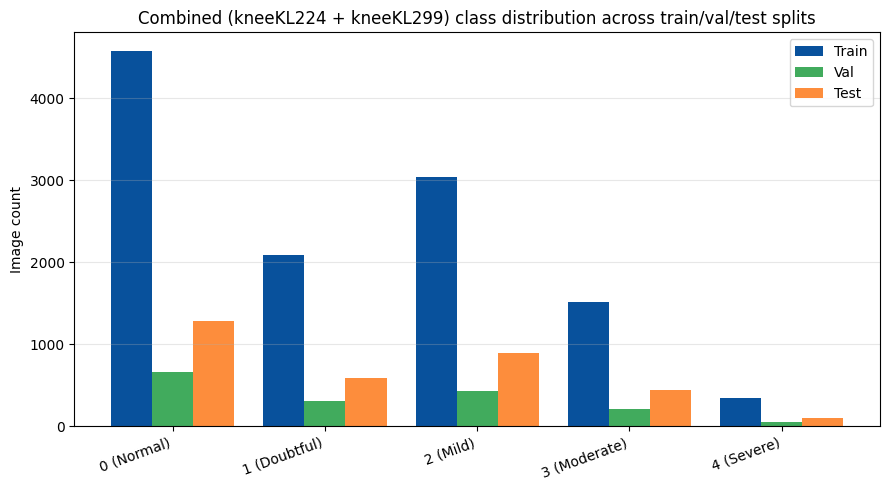

In [ ]:
def render_df_table(df, title, fname, fontsize=9, left_cols=(), shorten_cols=()):
    # renders a DataFrame as a clean matplotlib table with content-proportional column
    # widths (no overlapping text), zebra striping and a shaded header
    d = df.copy()
    d = d.astype(str)
    nrow, ncol = d.shape
    chars = [max(len(str(c)), int(d[c].map(len).max()) if nrow else 0) for c in d.columns]
    total = max(1, sum(chars))
    colw  = [c/total for c in chars]
    fig_w = min(24, max(7.0, 0.14*total + 2.0))
    fig_h = 0.5*nrow + 1.3
    fig, ax = plt.subplots(figsize=(fig_w, fig_h)); ax.axis("off")
    tbl = ax.table(cellText=d.values, colLabels=list(d.columns), loc="center",
                   cellLoc="center", colWidths=colw)
    tbl.auto_set_font_size(False); tbl.set_fontsize(fontsize); tbl.scale(1, 1.5)
    for (r, cc), cell in tbl.get_celld().items():
        cell.set_edgecolor("#cccccc")
        if r == 0:
            cell.set_text_props(fontweight="bold", color="white"); cell.set_facecolor("#3b5b92")
        else:
            cell.set_facecolor("#eef2f8" if r % 2 else "white")
            if d.columns[cc] in left_cols:
                cell.set_text_props(ha="left"); cell.PAD = 0.03
    ax.set_title(title, fontweight="bold", fontsize=13, pad=14)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=170, bbox_inches="tight"); plt.show()

for sz, df in tables_by_variant.items():
    render_df_table(df, f"Dataset composition — kneeKL{sz} — images per KL grade × split",
                    f"table_dataset_composition_kneeKL{sz}.png", left_cols=("KL Grade",))

render_df_table(combined_table, "Dataset composition — COMBINED (kneeKL224 + kneeKL299) — "
                "images per KL grade × split (used for training)",
                "table_dataset_composition_combined.png", left_cols=("KL Grade",))

# ---- classwise distribution bar chart (combined data actually used for training) ----
plot_df = combined_table.iloc[:-1]
x = np.arange(len(plot_df)); w = 0.27
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x-w, plot_df["Train"], w, label="Train", color="#08519c")
ax.bar(x,   plot_df["Val"],   w, label="Val",   color="#41ab5d")
ax.bar(x+w, plot_df["Test"],  w, label="Test",  color="#fd8d3c")
ax.set_xticks(x); ax.set_xticklabels(plot_df["KL Grade"], rotation=20, ha="right")
ax.set_ylabel("Image count"); ax.legend(); ax.grid(axis="y", alpha=0.3)
ax.set_title("Combined (kneeKL224 + kneeKL299) class distribution across train/val/test splits")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "bar_dataset_composition_combined.png"), dpi=160,
                                bbox_inches="tight"); plt.show()

## §4 · Preprocessing — CLAHE → Otsu → morphology ROI crop

Same fast preprocessing pipeline as the reference benchmark: grayscale → CLAHE (contrast-limited
adaptive histogram equalisation) → Otsu threshold → morphological close/open → largest-contour
bounding-box crop. This runs inside every epoch (milliseconds/image), so it is applied identically
for all 6 models.

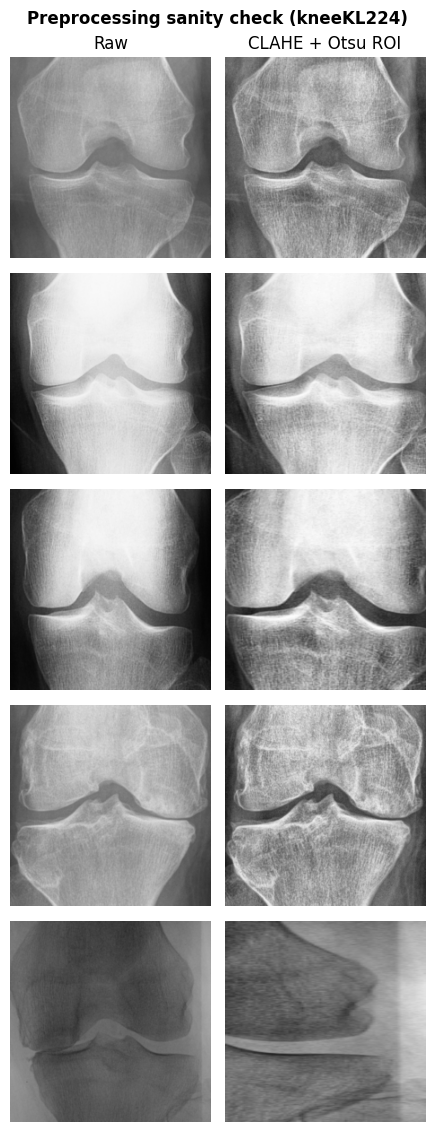

In [ ]:
def _to_uint8(g):
    # coerces any grayscale array (8/16-bit, float) to single-channel uint8
    g = np.asarray(g)
    if g.ndim == 3:
        g = g[:, :, 0]
    if g.dtype == np.uint8:
        return np.ascontiguousarray(g)
    g = g.astype(np.float32)
    mn, mx = float(np.nanmin(g)), float(np.nanmax(g))
    g = (g - mn) / (mx - mn) * 255.0 if mx > mn else np.zeros_like(g)
    return np.ascontiguousarray(g.astype(np.uint8))

def _clahe(gray):
    return cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)

def _largest_contour_bbox(binary):
    cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None, None
    c = max(cnts, key=cv2.contourArea)
    return c, cv2.boundingRect(c)

def _bbox_crop(cl, mask, img_size):
    # a degenerate Otsu/morphology mask (too small, or near-full-frame) crops away the joint
    # instead of isolating it -- fall back to the CLAHE full frame instead of feeding a
    # near-blank or truncated ROI into every model
    contour, bbox = _largest_contour_bbox(mask)
    if bbox is not None:
        x, y, w, h = bbox
        frame_area = img_size * img_size
        bbox_area = w * h
        if not (0.15 * frame_area <= bbox_area <= 0.97 * frame_area):
            return cl
        px, py = int(0.08*w), int(0.10*h)
        x1, y1 = max(0, x-px), max(0, y-py)
        x2, y2 = min(img_size, x+w+px), min(img_size, y+h+py)
        roi = cl[y1:y2, x1:x2]
        roi = roi if roi.size else cl
    else:
        roi = cl
    return roi

def auto_knee_segment(gray, img_size):
    # grayscale -> CLAHE -> Otsu -> morphology -> largest-contour bbox crop (fast ROI path)
    gray = _to_uint8(gray)
    gray = cv2.resize(gray, (img_size, img_size))
    cl = _clahe(gray)
    blur = cv2.GaussianBlur(cl, (5, 5), 0)
    _, thb = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    mask = cv2.morphologyEx(thb, cv2.MORPH_CLOSE, k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    return _bbox_crop(cl, mask, img_size)

def load_image(path, img_size, preprocess=True):
    # read -> (optional) segment+enhance -> 3-channel uint8 RGB for pretrained backbones.
    # retries transient I/O misses (Google-Drive FUSE can momentarily fail on an existing file)
    img = None
    for attempt in range(4):
        try:
            buf = np.fromfile(path, dtype=np.uint8)
            if buf.size:
                img = cv2.imdecode(buf, cv2.IMREAD_UNCHANGED)
            if img is not None:
                break
        except (FileNotFoundError, OSError):
            pass
        time.sleep(0.25 * (attempt + 1))
    if img is None:
        raise FileNotFoundError(path)
    gray = cv2.cvtColor(img[:, :, :3], cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    g = auto_knee_segment(gray, img_size) if preprocess else _to_uint8(gray)
    g = _to_uint8(cv2.resize(g, (img_size, img_size)))
    return np.stack([g, g, g], axis=-1)

# quick visual sanity check: raw vs preprocessed, one sample per class (kneeKL224)
fig, axes = plt.subplots(num_classes, 2, figsize=(4.5, 2.3*num_classes))
for i, c in enumerate(labels):
    files = glob.glob(os.path.join(VARIANT_DIRS[224], "train", c, "*"))
    if not files:
        continue
    axes[i, 0].imshow(load_image(files[0], 224, False)); axes[i, 0].axis("off")
    axes[i, 1].imshow(load_image(files[0], 224, True));  axes[i, 1].axis("off")
    axes[i, 0].set_ylabel(f"G{c}:{class_short[i]}", fontsize=9)
axes[0, 0].set_title("Raw"); axes[0, 1].set_title("CLAHE + Otsu ROI")
fig.suptitle("Preprocessing sanity check (kneeKL224)", fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "preprocessing_sanity_check.png"), dpi=140,
                                bbox_inches="tight"); plt.show()

## §5 · Datasets, transforms & loaders (both dataset folders pooled)

`KneeDataset` now takes **all variant roots** (`kneeKL224` *and* `kneeKL299`) and, for a given
split, concatenates the file lists from every root — so the effective train/val/test sets are the
**union** of both folders (matching the combined counts printed in §3). Every image is resized to
the target model's native `img_size` (224 or 299) at load time regardless of which folder it came
from, so this works uniformly for all 6 models. Loaders are cached per `img_size`.

In [ ]:
from torch.utils.data import WeightedRandomSampler

def build_transforms(img_size):
    # Stronger, radiograph-safe training augmentation. RandomResizedCrop + affine translate give
    # scale/position invariance; mild brightness/contrast jitter mimics exposure variation;
    # RandomErasing acts as structured dropout. No hue/solarize/posterize (would corrupt the
    # grayscale bone contrast the grader relies on).
    train_tf = T.Compose([
        T.ToPILImage(),
        T.RandomResizedCrop(img_size, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(15),
        T.RandomAffine(degrees=0, translate=(0.06, 0.06)),
        T.ColorJitter(brightness=0.15, contrast=0.15),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        T.RandomErasing(p=0.25, scale=(0.02, 0.12)),
    ])
    eval_tf = T.Compose([
        T.ToPILImage(), T.Resize((img_size, img_size)),
        T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
    return train_tf, eval_tf

class KneeDataset(Dataset):
    def __init__(self, variant_roots, split, classes, img_size, preprocess, transforms, subset=None):
        self.img_size, self.preprocess, self.transforms = img_size, preprocess, transforms
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.samples = []
        for root in variant_roots:                         # pool kneeKL224 + kneeKL299
            for c in classes:
                for f in sorted(glob.glob(os.path.join(root, split, c, "*"))):
                    self.samples.append((f, self.class_to_idx[c]))
        if subset:
            random.Random(SEED).shuffle(self.samples)
            self.samples = self.samples[:subset]
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        for _ in range(5):
            path, y = self.samples[i]
            try:
                img = load_image(path, self.img_size, self.preprocess)
                return self.transforms(img), y, path
            except Exception:
                i = random.randint(0, len(self.samples) - 1)
        path, y = self.samples[i]
        return self.transforms(load_image(path, self.img_size, self.preprocess)), y, path

def _make_sampler(train_ds):
    # WeightedRandomSampler: every sample's draw-probability is inverse to its class frequency, so
    # each mini-batch is (in expectation) class-balanced -- directly attacks the low Doubtful/Mild
    # recall without throwing away majority-class data.
    y = np.array([t for _, t in train_ds.samples])
    class_count = np.bincount(y, minlength=num_classes).astype(np.float64)
    class_w = 1.0 / np.clip(class_count, 1, None)
    sample_w = class_w[y]
    return WeightedRandomSampler(torch.as_tensor(sample_w, dtype=torch.double),
                                 num_samples=len(sample_w), replacement=True)

def make_loaders(img_size, preprocess=True, subset=SUBSET):
    variant_roots = list(VARIANT_DIRS.values())            # kneeKL224 + kneeKL299 combined
    train_tf, eval_tf = build_transforms(img_size)
    tr = KneeDataset(variant_roots, "train", labels, img_size, preprocess, train_tf, subset)
    va = KneeDataset(variant_roots, "val",   labels, img_size, preprocess, eval_tf,  subset)
    te = KneeDataset(variant_roots, "test",  labels, img_size, preprocess, eval_tf,  None)
    nw = 2
    if USE_SAMPLER:
        train_loader = DataLoader(tr, batch_size=BATCH_SIZE, sampler=_make_sampler(tr),
                                  num_workers=nw, pin_memory=True, drop_last=True)
    else:
        train_loader = DataLoader(tr, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=nw, pin_memory=True, drop_last=True)
    return (tr, va, te,
            train_loader,
            DataLoader(va, batch_size=BATCH_SIZE, shuffle=False, num_workers=nw, pin_memory=True),
            DataLoader(te, batch_size=BATCH_SIZE, shuffle=False, num_workers=nw, pin_memory=True))

def compute_weights(train_ds):
    y = np.array([t for _, t in train_ds.samples])
    w = compute_class_weight("balanced", classes=np.arange(num_classes), y=y)
    return torch.tensor(w, dtype=torch.float, device=device)

_LOADER_CACHE = {}
def get_loaders(img_size):
    if img_size not in _LOADER_CACHE:
        _LOADER_CACHE[img_size] = make_loaders(img_size)
        tr = _LOADER_CACHE[img_size][0]
        print(f"img_size={img_size}: pooled train={len(tr)} "
              f"val={len(_LOADER_CACHE[img_size][1])} test={len(_LOADER_CACHE[img_size][2])} "
              f"from {list(VARIANT_DIRS.values())} | sampler={USE_SAMPLER}")
    return _LOADER_CACHE[img_size]

print("Loaders built lazily per img_size (224/299), pooling both folders, with balanced sampling.")


## §6 · Model zoo — 6 architectures

Five backbones (ResNet50, InceptionV3, MobileNetV1, ViT-Base, Swin-Transformer) share the common
head **GAP → Dense(256, ReLU) → Dropout(0.4) → Dense(5)**. The sixth, **OA-HANet**, is the proposed
dual-head hybrid described below.

In [ ]:
AVAIL          = set(timm.list_models())
AVAIL_PRETRAIN = set(timm.list_models(pretrained=True))

def resolve(cands):
    for c in cands:
        if c in AVAIL_PRETRAIN: return c
    for c in cands:
        if c in AVAIL: return c
    return None

HEAD_HIDDEN = 256
def make_head(in_f, n=num_classes):
    return nn.Sequential(nn.Linear(in_f, HEAD_HIDDEN), nn.ReLU(),
                         nn.Dropout(0.4), nn.Linear(HEAD_HIDDEN, n))

class TimmClassifier(nn.Module):
    # standard single-backbone model with the shared head
    def __init__(self, cand):
        super().__init__()
        name = resolve(cand)
        if name is None:
            raise ValueError(f"No timm model available among {cand}")
        self.timm_name = name
        self.backbone = timm.create_model(name, pretrained=True, num_classes=0)
        self.head = make_head(self.backbone.num_features)
    def forward(self, x):
        return self.head(self.backbone(x))

def _to_tokens(x, channels_last):
    if x.dim() == 3:                     # already (B, N, C)
        return x
    if channels_last:                    # (B, H, W, C)  e.g. Swin
        B, H, W, C = x.shape
        return x.reshape(B, H*W, C)
    B, C, H, W = x.shape                 # (B, C, H, W)  CNNs
    return x.permute(0, 2, 3, 1).reshape(B, H*W, C)

print("Shared head + token-reshape helpers ready.")

Shared head + token-reshape helpers ready.


### §6B · OA-HANet (proposed) — Swin backbone + Multi-Scale CNN Reuse Branch + Cross-Attention Fusion + 2 auxiliary heads

* **Swin Transformer backbone** — hierarchical shifted-window self-attention capturing global joint
  geometry across multiple scales (queries).
* **Multi-Scale CNN Reuse Branch** — a `densenet121` feature extractor read at **3 dense-block
  stages** (DenseNet-style dense connectivity), each pooled to a common grid and projected to
  tokens, restoring fine local osteophyte and texture cues at multiple receptive fields (keys/values).
* **Cross-Attention Fusion Module** — Swin's global tokens cross-attend to the multi-scale local
  CNN tokens (residual + FFN block), then local-mean and global-mean pooling are concatenated
  before classification — combining global attention features with local convolutional features.
* **Ordinal-Aware Classification Head** — a scalar regressor trained with a **grade-distance
  (smooth-L1) loss**, penalising multi-grade errors more than adjacent-grade slips, honouring the
  ordered KL scale.
* **Early-Grade Discrimination Head** — a dedicated Normal-vs-Doubtful binary classifier plus a
  supervised-contrastive projection, sharpening the hardest KL boundary (G0 vs G1).

The main 5-class head, ordinal head and early-grade head are trained jointly (multi-task); only the
**main head is used at prediction time**, so the two auxiliary heads act as training-time
regularisers on the fused representation.

In [ ]:
class MultiScaleCNNBranch(nn.Module):
    # DenseNet-style multi-scale CNN reuse branch: reads 3 dense-block stages and returns one
    # token set per scale (fine -> coarse), restoring local osteophyte/texture cues at multiple
    # receptive fields
    def __init__(self, cnn_name=None, out_indices=(2, 3, 4), pool_size=7):
        super().__init__()
        cnn_name = cnn_name or OAHANET_CNN
        self.backbone = timm.create_model(cnn_name, pretrained=True, features_only=True,
                                          out_indices=out_indices)
        self.pool = nn.AdaptiveAvgPool2d(pool_size)
        self.channels = self.backbone.feature_info.channels()
    def forward(self, x):
        feats = self.backbone(x)                       # list of (B, C_i, H_i, W_i), fine->coarse
        tokens = []
        for f in feats:
            f = self.pool(f)                            # unify spatial grid across scales
            B, C, H, W = f.shape
            tokens.append(f.permute(0, 2, 3, 1).reshape(B, H*W, C))
        return tokens                                   # list[(B, 49, C_i)]

class OAHANet(nn.Module):
    # proposed OA-HANet: Swin backbone (global) x multi-scale DenseNet reuse branch (local)
    # fused by cross-attention, with an ordinal-aware head and an early-grade discrimination head
    def __init__(self, swin_name=None, cnn_name=None, dim=384, heads=8, img_size=224):
        super().__init__()
        swin_name = swin_name or SWIN_BACKBONE
        cnn_name  = cnn_name or OAHANET_CNN
        self.timm_name = f"{swin_name}(global)x{cnn_name}(multi-scale-local)+xattn"
        self.swin = timm.create_model(swin_name, pretrained=True, num_classes=0, global_pool='')
        self.cnn  = MultiScaleCNNBranch(cnn_name)
        with torch.no_grad():
            d = torch.zeros(1, 3, img_size, img_size)
            s = _to_tokens(self.swin.forward_features(d), channels_last=True)
        self.sproj = nn.Linear(s.shape[-1], dim)
        self.cproj = nn.ModuleList([nn.Linear(c, dim) for c in self.cnn.channels])
        self.ln_s  = nn.LayerNorm(dim)
        self.ln_c  = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, batch_first=True, dropout=0.1)
        self.ln_ff = nn.LayerNorm(dim)
        self.ffn   = nn.Sequential(nn.Linear(dim, dim*2), nn.GELU(),
                                   nn.Dropout(0.1), nn.Linear(dim*2, dim))
        # (1) main 5-class head: concat(Swin pool, multi-scale CNN pool)
        self.head = make_head(dim*2)
        # (2) Ordinal-aware head — regresses a continuous KL grade; grade-distance loss.
        self.ord_head = nn.Linear(dim*2, 1)
        # (3) Early-grade discrimination head — Normal-vs-Doubtful classifier + contrastive proj.
        self.eg_head = nn.Linear(dim*2, 2)
        self.eg_proj = nn.Sequential(nn.Linear(dim*2, 128), nn.ReLU(), nn.Linear(128, 64))

    def fused_features(self, x):
        s = self.sproj(_to_tokens(self.swin.forward_features(x), True))        # global queries
        scale_tokens = self.cnn(x)
        c = torch.cat([proj(t) for proj, t in zip(self.cproj, scale_tokens)], dim=1)  # local K/V
        a, _ = self.attn(self.ln_s(s), self.ln_c(c), self.ln_c(c))
        s = s + a                                                              # cross-attn residual
        s = s + self.ffn(self.ln_ff(s))                                        # FFN residual
        return torch.cat([s.mean(dim=1), c.mean(dim=1)], dim=1)                # local + global

    def forward(self, x):
        return self.head(self.fused_features(x))

    def forward_multi(self, x):
        f = self.fused_features(x)
        return (self.head(f), self.ord_head(f).squeeze(-1),
                self.eg_head(f), F.normalize(self.eg_proj(f), dim=1))

print("OA-HANet defined:", OAHANET_CNN, "x", SWIN_BACKBONE)

OA-HANet defined: densenet121 x swin_base_patch4_window7_224


In [ ]:
# -------- the 6-model registry --------
# 'img_size' is only the model's native resize target — every model's loader still pools BOTH
# kneeKL224 and kneeKL299 (see §5 get_loaders); img_size just controls the on-the-fly resize.
MODEL_SPECS = {
    "ResNet50":         dict(img_size=224, multihead=False, builder=lambda: TimmClassifier(["resnet50"])),
    "InceptionV3":      dict(img_size=299, multihead=False, builder=lambda: TimmClassifier(["inception_v3"])),
    "MobileNetV1":      dict(img_size=224, multihead=False,
                             builder=lambda: TimmClassifier(["mobilenetv1_100",
                                                             "mobilenetv1_100.ra4_e3600_r224_in1k",
                                                             "mobilenet_100"])),
    "ViT-Base":         dict(img_size=224, multihead=False, builder=lambda: TimmClassifier(["vit_base_patch16_224"])),
    "Swin-Transformer": dict(img_size=224, multihead=False,
                             builder=lambda: TimmClassifier([SWIN_BACKBONE, "swin_tiny_patch4_window7_224"])),
    "OA-HANet":         dict(img_size=224, multihead=True, builder=lambda: OAHANet(img_size=224)),
}
MODEL_NAMES = list(MODEL_SPECS.keys())

BACKBONE_USED = {}
for m, spec in MODEL_SPECS.items():
    try:
        probe = spec["builder"]()
        BACKBONE_USED[m] = getattr(probe, "timm_name", m)
        del probe
    except Exception as e:
        BACKBONE_USED[m] = f"ERROR: {e}"
    gc.collect(); torch.cuda.empty_cache() if device.type == "cuda" else None

print(f"{len(MODEL_NAMES)} models registered (all trained on the COMBINED kneeKL224+kneeKL299 pool):")
for m in MODEL_NAMES:
    print(f"  • {m:18s} (native img {MODEL_SPECS[m]['img_size']}) -> {BACKBONE_USED[m]}"
          f"{'  [multi-head: +ordinal +early-grade]' if MODEL_SPECS[m]['multihead'] else ''}")

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/17.0M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

6 models registered (all trained on the COMBINED kneeKL224+kneeKL299 pool):
  • ResNet50           (native img 224) -> resnet50
  • InceptionV3        (native img 299) -> inception_v3
  • MobileNetV1        (native img 224) -> mobilenetv1_100.ra4_e3600_r224_in1k
  • ViT-Base           (native img 224) -> vit_base_patch16_224
  • Swin-Transformer   (native img 224) -> swin_base_patch4_window7_224
  • OA-HANet           (native img 224) -> swin_base_patch4_window7_224(global)xdensenet121(multi-scale-local)+xattn  [multi-head: +ordinal +early-grade]


## §7 · Layer-wise fine-tuning control

`set_finetune(model, n_last)` freezes the whole backbone, then unfreezes only its last `n_last`
parameterised leaf layers (`n_last=0` freezes the entire backbone — used for phase A's head-only
warm-up; `n_last>=` the total leaf count would unfreeze it entirely, for an optional full
fine-tune). §2 sets `UNFREEZE_LAST=20` and `FULL_FINETUNE=False`, so phase B (§8) unfreezes just
the **last 20** parameterised leaf layers of every backbone — the same fine-tuning depth for all 6
models (unified benchmark protocol). The custom head / fusion / auxiliary-head modules are always
trainable regardless of `n_last`.

In [ ]:
from collections import defaultdict

def _backbone_leaf_modules(model):
    # returns backbone leaf modules in SHALLOW->DEEP order (module registration order), which for
    # timm backbones tracks depth from input to output -- used both for partial unfreeze and for
    # assigning layer-wise-decayed learning rates.
    bbs = []
    for attr in ("backbone", "swin", "cnn"):
        if hasattr(model, attr):
            bbs.append(getattr(model, attr))
    if not bbs:
        bbs = [model]
    leaves = []
    for bb in bbs:
        for m in bb.modules():
            if len(list(m.children())) == 0 and len(list(m.parameters(recurse=False))) > 0:
                leaves.append(m)
    return leaves

# names of the new (non-pretrained) sub-modules that always train AND get the HEAD_LR
NEW_MODULE_ATTRS = ("head", "sproj", "cproj", "attn", "ln_s", "ln_c", "ln_ff", "ffn",
                    "ord_head", "eg_head", "eg_proj")

def _new_param_ids(model):
    ids = set()
    for attr in NEW_MODULE_ATTRS:
        if hasattr(model, attr):
            ids.update(id(p) for p in getattr(model, attr).parameters())
    return ids

FULL_UNFREEZE_N = 10**9   # sentinel: n_last this large always unfreezes the entire backbone

def set_finetune(model, n_last):
    # n_last=0 freezes the whole backbone (leaves[-0:]==leaves[:], so 0 is special-cased);
    # n_last>=len(leaves) (or FULL_UNFREEZE_N) unfreezes it entirely (full fine-tuning).
    for p in model.parameters():
        p.requires_grad = False
    leaves = _backbone_leaf_modules(model)
    if n_last > 0:
        for m in leaves[-n_last:]:
            for p in m.parameters(recurse=False):
                p.requires_grad = True
    for attr in NEW_MODULE_ATTRS:
        if hasattr(model, attr):
            for p in getattr(model, attr).parameters():
                p.requires_grad = True
    n_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_all = sum(p.numel() for p in model.parameters())
    return n_tr, n_all

def make_param_groups(model, head_lr=None, backbone_lr=None, llrd=None):
    # LAYER-WISE LR DECAY (LLRD): each backbone leaf module gets a learning rate that decays the
    # shallower (closer to the input) it sits -- lr = backbone_lr * llrd**(depth_from_top). New
    # head/fusion/auxiliary modules train at the larger head_lr. Only requires_grad params are
    # included, so this is correct for both the frozen warm-up (phase A) and full FT (phase B).
    head_lr     = HEAD_LR      if head_lr     is None else head_lr
    backbone_lr = BACKBONE_LR  if backbone_lr is None else backbone_lr
    llrd        = LLRD_DECAY   if llrd        is None else llrd

    new_ids = _new_param_ids(model)
    leaves  = _backbone_leaf_modules(model)
    n = len(leaves)
    param_depth = {}
    for depth, m in enumerate(leaves):                      # 0 = shallowest, n-1 = deepest
        for p in m.parameters(recurse=False):
            param_depth[id(p)] = depth

    groups = []
    new_params = [p for p in model.parameters() if p.requires_grad and id(p) in new_ids]
    if new_params:
        groups.append({"params": new_params, "lr": head_lr})

    buckets = defaultdict(list)
    for p in model.parameters():
        if not p.requires_grad or id(p) in new_ids:
            continue
        d = param_depth.get(id(p), n - 1)                   # unmatched trunk params -> top group
        buckets[d].append(p)
    for d, ps in buckets.items():
        scale = llrd ** (n - 1 - d)                         # deepest (d=n-1) -> scale 1.0
        groups.append({"params": ps, "lr": backbone_lr * scale})
    return groups

print("Layer-wise fine-tuning + LLRD param groups ready.")


## §8 · Training / evaluation engine (2-phase full fine-tune, EMA, early-stop on balanced val-acc)

`train_model(name)` runs every model through the same **2-phase** protocol:

* **Phase A (warm-up, `WARMUP_EPOCHS`)** — backbone fully frozen (`set_finetune(model, 0)`), only the
  new head / fusion / auxiliary modules train at `HEAD_LR`. Stabilises the randomly-initialised head
  before any backbone gradients flow.
* **Phase B (full fine-tune)** — the **entire backbone is unfrozen** (`FULL_FINETUNE=True`) and trained
  with **layer-wise LR decay** (deep layers fast, shallow layers slow), a **linear-warmup → cosine**
  schedule, and **global-norm gradient clipping**.

Additional accuracy mechanisms:
* **EMA** — an exponential moving average of the weights is kept; validation, checkpointing and the
  final test all use the **EMA copy**, which generalises better than the raw SGD iterate.
* **Balanced-accuracy early stopping** — the kept checkpoint is the epoch with the highest *balanced*
  validation accuracy (mean per-class recall), so the minority Doubtful/Mild grades count as much as
  the majority Normal grade. Patience = `PATIENCE`.
* **Test-Time Augmentation** — `predict()` averages the softmax logits of each test image and its
  horizontal flip (`USE_TTA`).


In [ ]:
from sklearn.metrics import balanced_accuracy_score

AMP_ON = bool(USE_AMP) and device.type == "cuda"


class EarlyStopping:
    # maximises the monitored metric (balanced val-accuracy); keeps a deep copy of the best state
    def __init__(self, patience=20, delta=1e-4):
        self.patience, self.delta = patience, delta
        self.best, self.counter, self.stop, self.best_state = None, 0, False, None
    def step(self, metric, state_model):
        if self.best is None or metric > self.best + self.delta:
            self.best, self.counter = metric, 0
            self.best_state = copy.deepcopy(state_model.state_dict())
        else:
            self.counter += 1
            self.stop = self.counter >= self.patience


class ModelEMA:
    # exponential moving average of model weights; the EMA copy is what gets evaluated & saved
    def __init__(self, model, decay=0.9995):
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)
        self.decay = decay
    @torch.no_grad()
    def update(self, model):
        d = self.decay
        for e, m in zip(self.ema.state_dict().values(), model.state_dict().values()):
            if e.dtype.is_floating_point:
                e.mul_(d).add_(m.detach().to(e.dtype), alpha=1.0 - d)
            else:
                e.copy_(m)


def _clip_and_step(model, optimizer, scaler):
    if scaler is not None:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_((p for p in model.parameters() if p.requires_grad), GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
    else:
        torch.nn.utils.clip_grad_norm_((p for p in model.parameters() if p.requires_grad), GRAD_CLIP)
        optimizer.step()


def hybrid_multitask_loss(main, ordp, eg_logits, eg_emb, y, class_w):
    L_cls = F.cross_entropy(main, y, weight=class_w, label_smoothing=LABEL_SMOOTHING)
    L_ord = F.smooth_l1_loss(ordp, y.float())                                   # grade-distance loss
    m = (y == 0) | (y == 1)                                                     # Normal vs Doubtful
    if int(m.sum()) >= 2:
        L_eg = F.cross_entropy(eg_logits[m], y[m])
        e, lab = eg_emb[m], y[m]
        sim = (e @ e.t()) / EG_TEMP
        eye = torch.eye(len(lab), device=e.device)
        same = (lab.unsqueeze(0) == lab.unsqueeze(1)).float() - eye
        logp = F.log_softmax(sim - eye * 1e9, dim=1)
        denom = same.sum(1).clamp(min=1)
        L_con = -(same * logp).sum(1) / denom
        L_eg = L_eg + 0.5 * L_con.mean()
    else:
        L_eg = torch.zeros((), device=main.device)
    return L_cls + ORD_LOSS_W * L_ord + EG_LOSS_W * L_eg


def _forward_loss(model, spec, imgs, y, class_w, criterion):
    if spec["multihead"]:
        main, ordp, eg_logits, eg_emb = model.forward_multi(imgs)
        loss = hybrid_multitask_loss(main, ordp, eg_logits, eg_emb, y, class_w)
        return main, loss
    out = model(imgs)
    return out, criterion(out, y)


def train_one_epoch(model, spec, loader, class_w, optimizer, scaler, ema):
    model.train()
    criterion = None if spec["multihead"] else nn.CrossEntropyLoss(weight=class_w,
                                                                   label_smoothing=LABEL_SMOOTHING)
    running, preds, tgts = 0.0, [], []
    for imgs, y, _ in loader:
        imgs, y = imgs.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=AMP_ON):
            out, loss = _forward_loss(model, spec, imgs, y, class_w, criterion)
        if scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()
        _clip_and_step(model, optimizer, scaler)
        if ema is not None:
            ema.update(model)
        running += loss.item() * imgs.size(0)
        preds.extend(out.argmax(1).detach().cpu().tolist()); tgts.extend(y.cpu().tolist())
    return running / len(loader.dataset), accuracy_score(tgts, preds)


@torch.no_grad()
def eval_model(model, spec, loader, class_w):
    # returns (val_loss, balanced_val_acc, plain_val_acc); balanced acc is what early-stopping uses
    model.eval()
    criterion = None if spec["multihead"] else nn.CrossEntropyLoss(weight=class_w,
                                                                   label_smoothing=LABEL_SMOOTHING)
    running, preds, tgts = 0.0, [], []
    for imgs, y, _ in loader:
        imgs, y = imgs.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=AMP_ON):
            out, loss = _forward_loss(model, spec, imgs, y, class_w, criterion)
        running += loss.item() * imgs.size(0)
        preds.extend(out.argmax(1).cpu().tolist()); tgts.extend(y.cpu().tolist())
    return (running / len(loader.dataset),
            balanced_accuracy_score(tgts, preds),
            accuracy_score(tgts, preds))


@torch.no_grad()
def predict(model, loader, tta=None):
    # optional test-time augmentation: average the logits of the image and its horizontal flip
    tta = USE_TTA if tta is None else tta
    model.eval(); P, Tt, PR, PATHS = [], [], [], []
    for imgs, y, paths in loader:
        imgs = imgs.to(device)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=AMP_ON):
            logits = model(imgs).float()
            if tta:
                logits = logits + model(torch.flip(imgs, dims=[3])).float()
        prob = torch.softmax(logits, 1).cpu().numpy()
        P.extend(prob.argmax(1)); Tt.extend(y.numpy()); PR.extend(prob); PATHS.extend(paths)
    return np.array(P), np.array(Tt), np.array(PR), PATHS


def _build_scheduler(optimizer, phase_budget, warmup_n):
    warmup_n = min(warmup_n, max(0, phase_budget - 1))
    if warmup_n > 0:
        return torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[
                torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=warmup_n),
                torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=max(1, phase_budget - warmup_n), eta_min=BACKBONE_LR * 0.01),
            ],
            milestones=[warmup_n])
    return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, phase_budget),
                                                      eta_min=BACKBONE_LR * 0.01)


def _run_phase(model, spec, tl, vl, class_w, optimizer, scheduler, scaler, ema,
               n_epochs, patience, hist, start_ep, max_epochs, verbose, phase_tag):
    es = EarlyStopping(patience=patience)
    ep = start_ep
    for _ in range(n_epochs):
        ep += 1
        trl, tra = train_one_epoch(model, spec, tl, class_w, optimizer, scaler, ema)
        eval_target = ema.ema if ema is not None else model      # evaluate the EMA copy
        vl_loss, vbal, vacc = eval_model(eval_target, spec, vl, class_w)
        if scheduler is not None:
            scheduler.step()
        for k, v in zip(("train_loss", "train_acc", "val_loss", "val_acc"),
                        (trl, tra, vl_loss, vacc)):
            hist[k].append(v)
        if verbose:
            cur_lr = optimizer.param_groups[-1]["lr"]
            print(f"   [{phase_tag}] ep {ep:3d}/{max_epochs} | tr_loss {trl:.4f} acc {tra:.4f} | "
                  f"val_loss {vl_loss:.4f} acc {vacc:.4f} bal_acc {vbal:.4f} | lr {cur_lr:.2e}")
        es.step(vbal, eval_target)
        if es.stop:
            if verbose: print(f"   [{phase_tag}] early stop @ {ep} (best bal_acc {es.best:.4f})")
            break
    return es, ep


def train_model(name, max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=True):
    # trains one model end-to-end (single-head or OA-HANet multi-head) via the 2-phase protocol:
    # head warm-up -> full backbone fine-tune with LLRD, EMA, cosine schedule and balanced-acc
    # early stopping. Returns a results dict.
    spec = MODEL_SPECS[name]
    img_size = spec["img_size"]
    tr, va, te, tl, vl, tel = get_loaders(img_size)      # pooled kneeKL224 + kneeKL299
    class_w = compute_weights(tr) if USE_CLASS_WEIGHTS else None

    t0 = time.time()
    model = spec["builder"]().to(device)
    hist = {k: [] for k in ("train_loss", "train_acc", "val_loss", "val_acc")}

    # ---- Phase A: head/fusion-only warm-up, backbone fully frozen ----
    warmup_n = min(WARMUP_EPOCHS, max_epochs)
    set_finetune(model, 0)
    ema_a = ModelEMA(model, EMA_DECAY) if USE_EMA else None
    opt_a = torch.optim.AdamW(make_param_groups(model), weight_decay=WEIGHT_DECAY)
    scaler_a = torch.cuda.amp.GradScaler(enabled=AMP_ON)
    es_a, ep = _run_phase(model, spec, tl, vl, class_w, opt_a, None, scaler_a, ema_a, warmup_n,
                          max(patience, warmup_n + 1), hist, 0, max_epochs, verbose, "warm-up")

    # ---- Phase B: full backbone fine-tune, LLRD, linear-warmup + cosine decay ----
    n_last = FULL_UNFREEZE_N if FULL_FINETUNE else UNFREEZE_LAST
    n_tr, n_all = set_finetune(model, n_last)
    ema_b = ModelEMA(model, EMA_DECAY) if USE_EMA else None     # fresh EMA over the full network
    phase_b_budget = max(1, max_epochs - ep)
    opt_b = torch.optim.AdamW(make_param_groups(model), weight_decay=WEIGHT_DECAY)
    scaler_b = torch.cuda.amp.GradScaler(enabled=AMP_ON)
    sched_b = _build_scheduler(opt_b, phase_b_budget, LR_WARMUP_EPOCHS)
    es_b, ep = _run_phase(model, spec, tl, vl, class_w, opt_b, sched_b, scaler_b, ema_b,
                          phase_b_budget, patience, hist, ep, max_epochs, verbose, "fine-tune")

    # phase-B (full fine-tune, EMA) is the authoritative best state
    if es_b.best_state is not None:
        model.load_state_dict(es_b.best_state)
    elif es_a.best_state is not None:
        model.load_state_dict(es_a.best_state)
    if SAVE_WEIGHTS:
        try:
            torch.save(model.state_dict(), os.path.join(CKPT_DIR, f"{name}.pt"))
        except Exception as e:
            print("   (could not save weights:", e, ")")
    train_time = time.time() - t0

    model.eval()
    with torch.no_grad():
        xb = next(iter(tel))[0][:min(16, BATCH_SIZE)].to(device)
        _ = model(xb)
        if device.type == "cuda": torch.cuda.synchronize()
        ti = time.time(); _ = model(xb)
        if device.type == "cuda": torch.cuda.synchronize()
        latency_ms = (time.time() - ti) / xb.size(0) * 1000

    yp, yt, ypr, paths = predict(model, tel)
    test_acc = accuracy_score(yt, yp)
    pr, rc, f1, _ = precision_recall_fscore_support(yt, yp, average="macro", zero_division=0)
    per_cls = precision_recall_fscore_support(yt, yp, labels=list(range(num_classes)), zero_division=0)

    res = dict(name=name, timm_name=getattr(model, "timm_name", name), img_size=img_size,
               history=hist, test_acc=float(test_acc),
               macro_precision=float(pr), macro_recall=float(rc), macro_f1=float(f1),
               per_class_precision=per_cls[0].tolist(), per_class_recall=per_cls[1].tolist(),
               per_class_f1=per_cls[2].tolist(),
               y_true=yt.tolist(), y_pred=yp.tolist(), y_prob=ypr.tolist(), paths=paths,
               params=int(n_all), trainable_params=int(n_tr),
               train_time_s=float(train_time), latency_ms=float(latency_ms),
               epochs_run=len(hist["train_loss"]), warmup_epochs=warmup_n,
               recipe_version=RECIPE_VERSION)
    with open(os.path.join(CKPT_DIR, f"{name}_result.json"), "w") as f:
        json.dump(res, f)
    del model, opt_a, opt_b, ema_a, ema_b
    gc.collect(); torch.cuda.empty_cache() if device.type == "cuda" else None
    return res


## §9 · Train & test all 6 models

Each model is trained independently and crash-isolated: an OOM or build failure on one model is
caught, logged, and the loop moves on. Re-running this cell **skips models already saved** in
`CKPT_DIR`, so you can resume after a disconnect **without losing progress or retraining models
that already finished**.

That resume-safety check only ever looks inside the current `BASE_RESULTS_DIR` (§2) — it has no
way to tell "same recipe, resuming" apart from "recipe changed, please retrain", so **changing
`BASE_RESULTS_DIR` to a new folder is the one thing that guarantees a completely clean run**: point
it at a path that doesn't exist yet and every model retrains from scratch, no matter what the
recipe was last time. `RECIPE_VERSION` is recorded alongside each cached result purely so you can
tell, after the fact, which recipe produced a given number — it is metadata only and does **not**
by itself force a retrain.

In [ ]:
print(f"BASE_RESULTS_DIR = {BASE_RESULTS_DIR}  (RECIPE_VERSION tag: '{RECIPE_VERSION}')")
print("To guarantee a clean run with no risk of reloading old checkpoints, "
      "change BASE_RESULTS_DIR in §2 to a new folder before Runtime -> Run all.")

RESULTS = {}

def already_done(name):
    p = os.path.join(CKPT_DIR, f"{name}_result.json")
    if os.path.exists(p):
        with open(p) as f: RESULTS[name] = json.load(f)
        return True
    return False

for name in MODEL_NAMES:
    if name in RESULTS or already_done(name):
        rv = RESULTS[name].get("recipe_version", "unknown/pre-versioning")
        print(f"✓ {name}: loaded cached result (recipe={rv}, test_acc={RESULTS[name]['test_acc']:.4f})")
        continue
    print("\n" + "="*78 + f"\n  TRAINING: {name}" +
          ("  [multi-head: +ordinal +early-grade]" if MODEL_SPECS[name]["multihead"] else "") +
          "\n" + "="*78)
    try:
        RESULTS[name] = train_model(name)
        print(f"  >>> {name} TEST ACC = {RESULTS[name]['test_acc']*100:.2f}%  "
              f"(macro P/R/F1 = {RESULTS[name]['macro_precision']:.3f}/"
              f"{RESULTS[name]['macro_recall']:.3f}/{RESULTS[name]['macro_f1']:.3f})")
    except Exception as e:
        print(f"  !! {name} FAILED ({type(e).__name__}): {e}")
        traceback.print_exc()
        gc.collect(); torch.cuda.empty_cache() if device.type == "cuda" else None

print("\nTrained models:", list(RESULTS.keys()))
ranked = sorted(RESULTS, key=lambda n: RESULTS[n]["test_acc"], reverse=True)
print("\nRanking by test accuracy:")
for i, n in enumerate(ranked, 1):
    print(f"  {i}. {n:18s} {RESULTS[n]['test_acc']*100:.2f}%")
BEST2 = ranked[:2]
print("\nBEST 2 MODELS:", BEST2)

BASE_RESULTS_DIR = /content/drive/MyDrive/OA_HANet_6_results  (RECIPE_VERSION tag: 'v3_2phase_warmup_unfreeze20_cosine_clip')
To guarantee a clean run with no risk of reloading old checkpoints, change BASE_RESULTS_DIR in §2 to a new folder before Runtime -> Run all.

  TRAINING: ResNet50
img_size=224: pooled train=11556 val=1652 test=3312 from ['/content/oad_local/kneeKL224', '/content/oad_local/kneeKL299']
   [warm-up] ep   1/200 | tr_loss 1.7578 acc 0.1625 | val_loss 1.8668 acc 0.2669 | lr 7.50e-04
   [warm-up] ep   2/200 | tr_loss 1.7073 acc 0.2374 | val_loss 1.8292 acc 0.3674 | lr 7.50e-04
   [warm-up] ep   3/200 | tr_loss 1.6787 acc 0.2759 | val_loss 1.8307 acc 0.2978 | lr 7.50e-04
   [warm-up] ep   4/200 | tr_loss 1.6576 acc 0.2913 | val_loss 1.8311 acc 0.3226 | lr 7.50e-04
   [warm-up] ep   5/200 | tr_loss 1.6562 acc 0.2960 | val_loss 1.8108 acc 0.3674 | lr 7.50e-04
   [fine-tune] ep   6/200 | tr_loss 1.6346 acc 0.3339 | val_loss 1.8045 acc 0.3989 | lr 2.00e-05
   [fine-tune] ep

## §10 · Table — Train Acc / Train Loss / Val Acc / Val Loss (all 6 models)

           Model  Train Acc  Train Loss  Val Acc  Val Loss  Epochs
        ResNet50     0.5867      1.2729   0.5490    1.6367      62
     InceptionV3     0.5887      1.2642   0.5206    1.6546      44
     MobileNetV1     0.7058      1.1169   0.6174    1.5442      39
        ViT-Base     0.5838      1.2790   0.5672    1.5838      36
Swin-Transformer     0.6158      1.2359   0.5835    1.5732      45
        OA-HANet     0.6093      1.5875   0.5866    1.8195      57


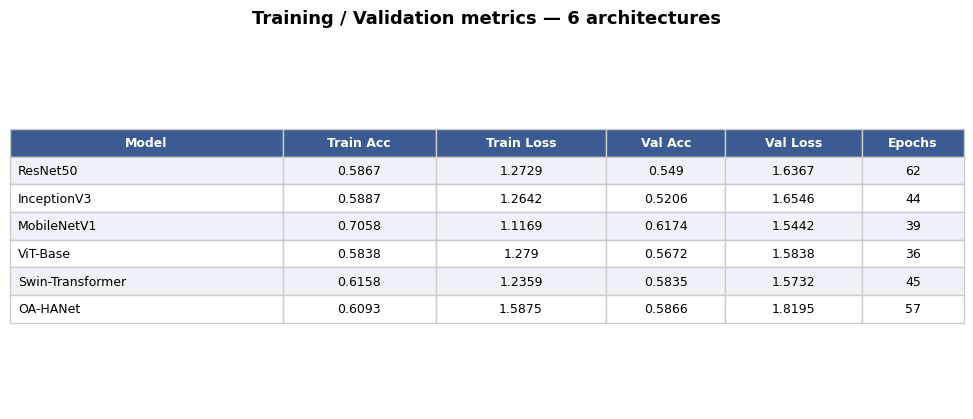

In [ ]:
def best_epoch_metrics(h):
    # picks the kept checkpoint epoch: the one with the highest val accuracy (early stopping now
    # monitors balanced val-accuracy, so val_acc -- not val_loss -- identifies the saved model)
    i = int(np.argmax(h["val_acc"]))
    return h["train_acc"][i], h["train_loss"][i], h["val_loss"][i], h["val_acc"][i]

rows = []
for n in MODEL_NAMES:
    if n not in RESULTS: continue
    ta, tl_, vl_, va = best_epoch_metrics(RESULTS[n]["history"])
    rows.append([n, round(ta,4), round(tl_,4), round(va,4), round(vl_,4), RESULTS[n]["epochs_run"]])
train_val_df = pd.DataFrame(rows, columns=["Model", "Train Acc", "Train Loss",
                                           "Val Acc", "Val Loss", "Epochs"])
train_val_df.to_csv(os.path.join(RESULTS_DIR, "table_train_val_metrics.csv"), index=False)
print(train_val_df.to_string(index=False))
render_df_table(train_val_df, "Training / Validation metrics — 6 architectures",
                "table_train_val_metrics.png", left_cols=("Model",))

## §11 · Learning curves — accuracy & loss (all 6 models)

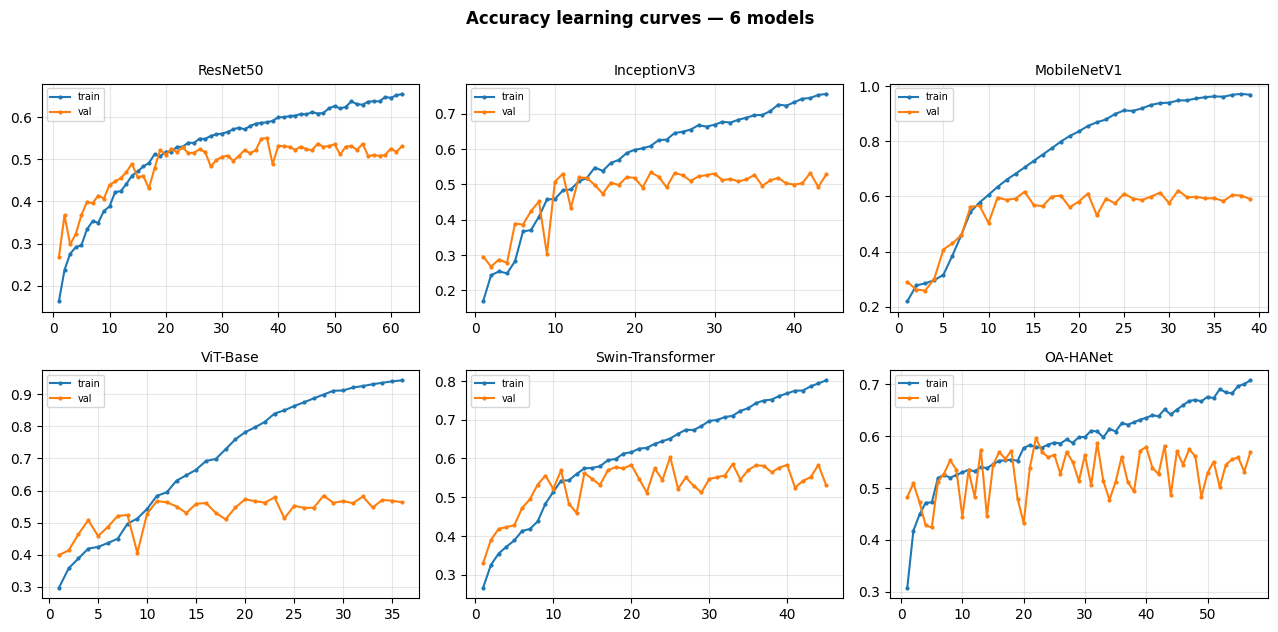

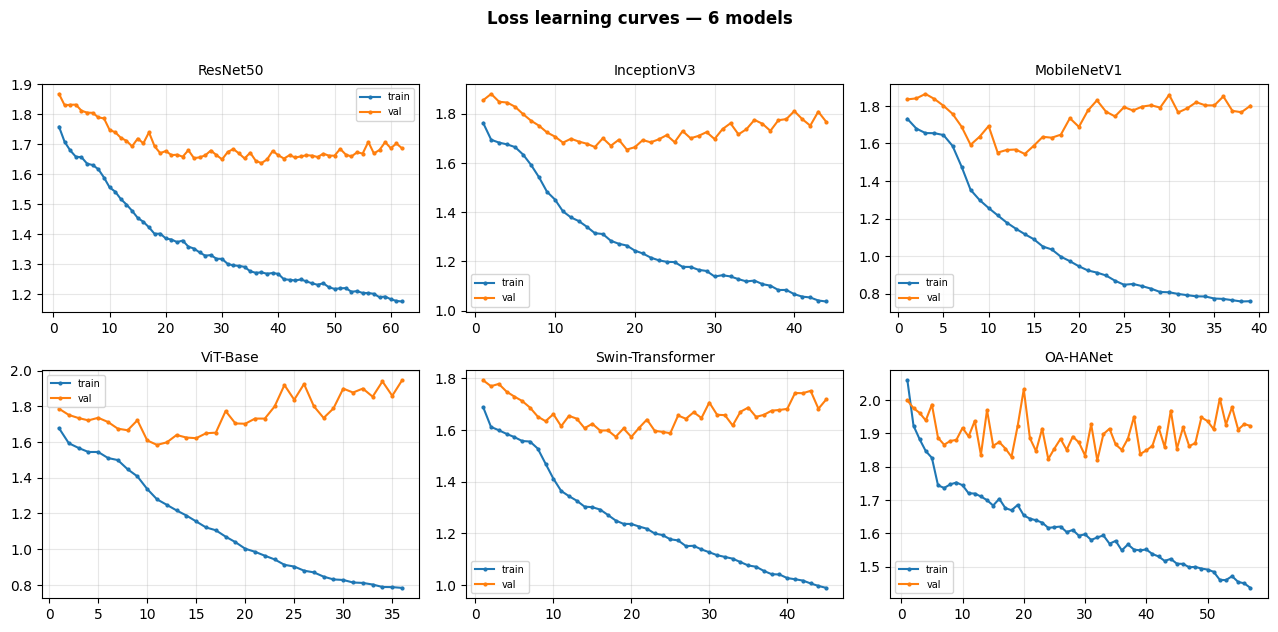

In [ ]:
order = [n for n in MODEL_NAMES if n in RESULTS]
ncol = 3; nrow = int(math.ceil(len(order)/ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(4.3*ncol, 3.2*nrow)); axes = np.atleast_1d(axes).ravel()
for i, n in enumerate(order):
    h = RESULTS[n]["history"]; ep = np.arange(1, len(h["train_acc"])+1)
    axes[i].plot(ep, h["train_acc"], "-o", ms=2, label="train")
    axes[i].plot(ep, h["val_acc"],   "-o", ms=2, label="val")
    axes[i].set_title(n, fontsize=10); axes[i].grid(alpha=0.3); axes[i].legend(fontsize=7)
for j in range(len(order), len(axes)): axes[j].axis("off")
fig.suptitle("Accuracy learning curves — 6 models", fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig(os.path.join(FIG_DIR, "learning_curves_accuracy_all.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(nrow, ncol, figsize=(4.3*ncol, 3.2*nrow)); axes = np.atleast_1d(axes).ravel()
for i, n in enumerate(order):
    h = RESULTS[n]["history"]; ep = np.arange(1, len(h["train_loss"])+1)
    axes[i].plot(ep, h["train_loss"], "-o", ms=2, label="train")
    axes[i].plot(ep, h["val_loss"],   "-o", ms=2, label="val")
    axes[i].set_title(n, fontsize=10); axes[i].grid(alpha=0.3); axes[i].legend(fontsize=7)
for j in range(len(order), len(axes)): axes[j].axis("off")
fig.suptitle("Loss learning curves — 6 models", fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig(os.path.join(FIG_DIR, "learning_curves_loss_all.png"), dpi=150, bbox_inches="tight")
plt.show()

## §12 · Confusion matrices (all 6 models)

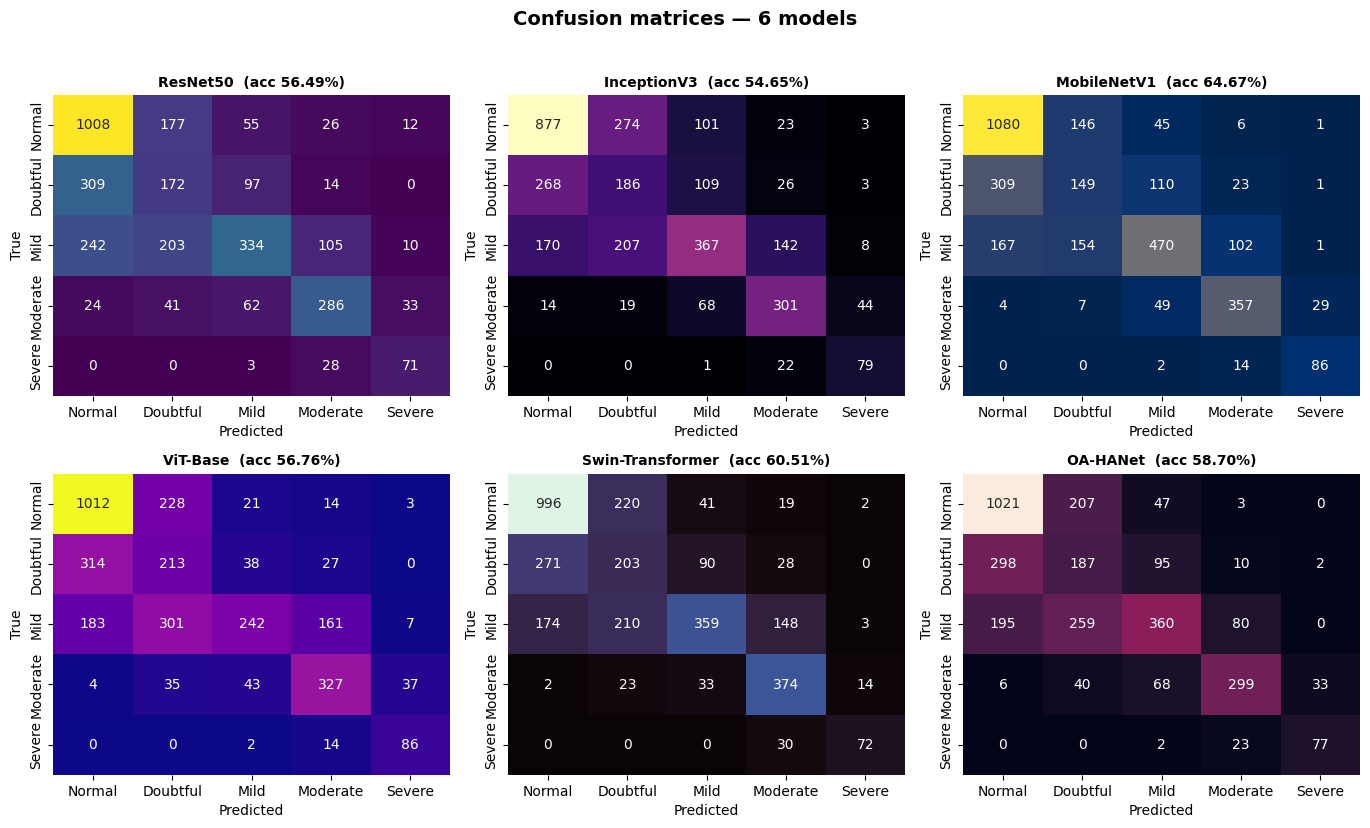

In [ ]:
ncol = 3; nrow = int(math.ceil(len(order)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6*ncol, 4.2*nrow)); axes = np.atleast_1d(axes).ravel()
cmaps = ["viridis", "magma", "cividis", "plasma", "mako", "rocket"]
for i, n in enumerate(order):
    cm = confusion_matrix(RESULTS[n]["y_true"], RESULTS[n]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmaps[i % len(cmaps)], ax=axes[i],
                xticklabels=class_short, yticklabels=class_short, cbar=False)
    axes[i].set_title(f"{n}  (acc {RESULTS[n]['test_acc']*100:.2f}%)", fontweight="bold", fontsize=10)
    axes[i].set_xlabel("Predicted"); axes[i].set_ylabel("True")
for j in range(len(order), len(axes)): axes[j].axis("off")
fig.suptitle("Confusion matrices — 6 models", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig(os.path.join(FIG_DIR, "confusion_matrix_all6.png"), dpi=170, bbox_inches="tight")
plt.show()

## §13 · Classwise classification metrics (precision / recall / F1)

           Model     KL Grade  Precision  Recall    F1
        ResNet50   0 (Normal)      63.68   78.87 70.46
        ResNet50 1 (Doubtful)      29.01   29.05 29.03
        ResNet50     2 (Mild)      60.62   37.36 46.23
        ResNet50 3 (Moderate)      62.31   64.13 63.20
        ResNet50   4 (Severe)      56.35   69.61 62.28
     InceptionV3   0 (Normal)      65.99   68.62 67.28
     InceptionV3 1 (Doubtful)      27.11   31.42 29.11
     InceptionV3     2 (Mild)      56.81   41.05 47.66
     InceptionV3 3 (Moderate)      58.56   67.49 62.71
     InceptionV3   4 (Severe)      57.66   77.45 66.11
     MobileNetV1   0 (Normal)      69.23   84.51 76.11
     MobileNetV1 1 (Doubtful)      32.68   25.17 28.44
     MobileNetV1     2 (Mild)      69.53   52.57 59.87
     MobileNetV1 3 (Moderate)      71.12   80.04 75.32
     MobileNetV1   4 (Severe)      72.88   84.31 78.18
        ViT-Base   0 (Normal)      66.89   79.19 72.52
        ViT-Base 1 (Doubtful)      27.41   35.98 31.12
        Vi

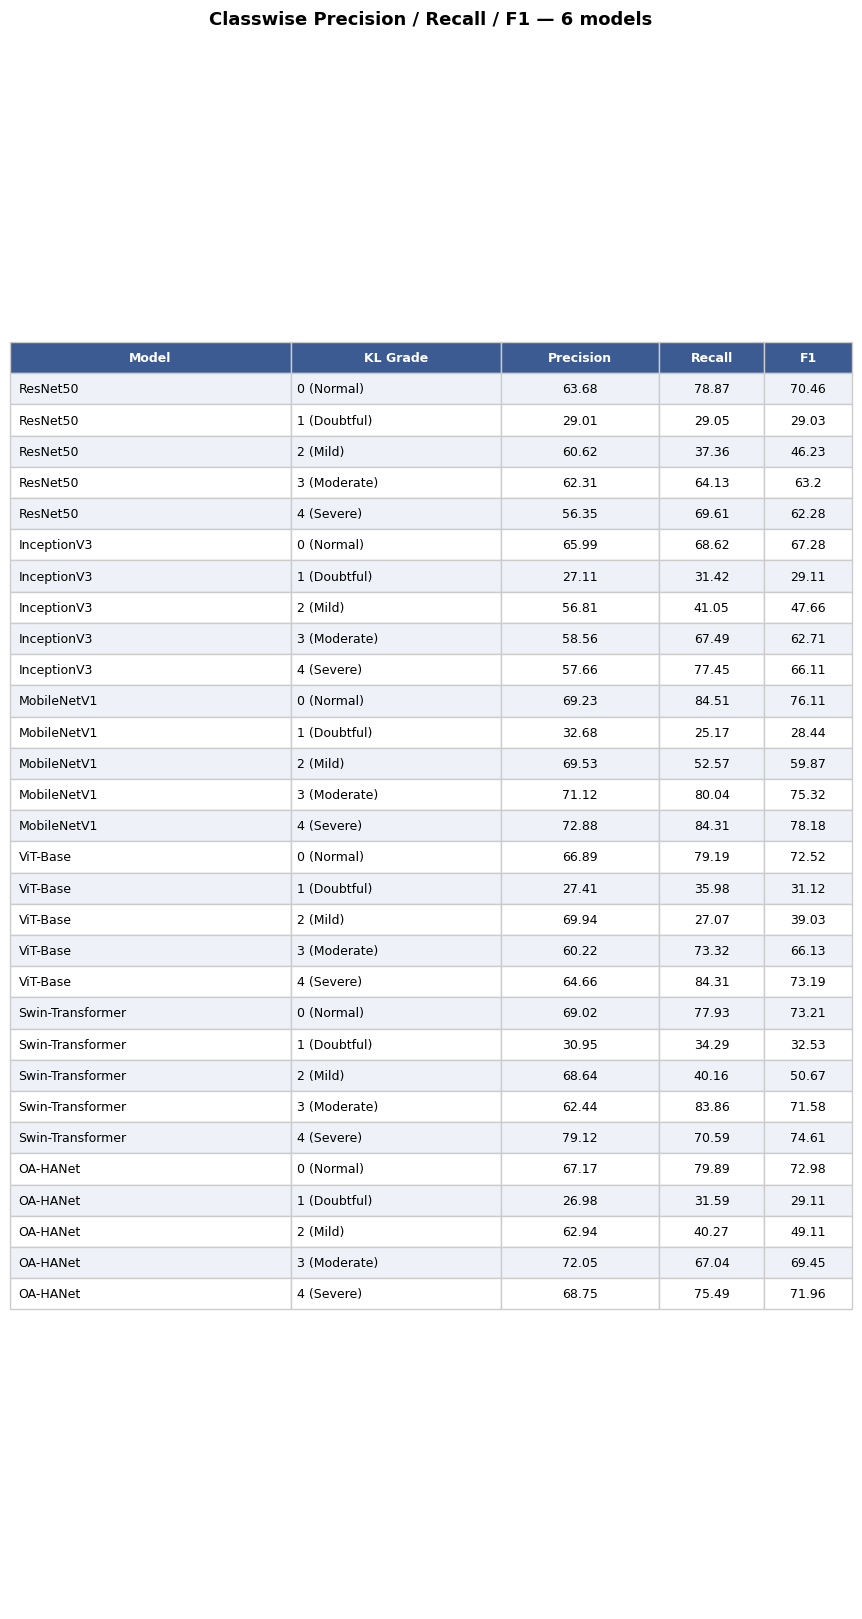

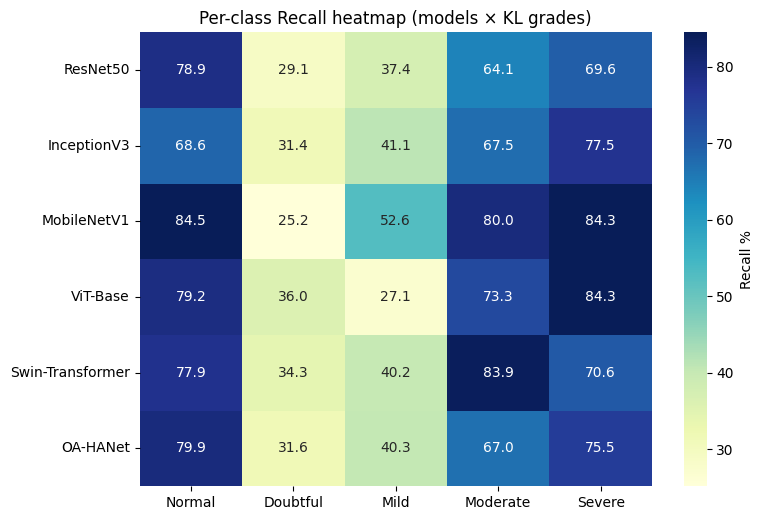


            Model  Avg Accuracy  Avg Precision  Avg Recall  Avg F1
     MobileNetV1         64.67          63.09       65.32   63.58
Swin-Transformer         60.51          62.03       61.37   60.52
        OA-HANet         58.70          59.58       58.86   58.52
        ViT-Base         56.76          57.82       59.97   56.40
        ResNet50         56.49          54.39       55.80   54.24
     InceptionV3         54.65          53.23       57.21   54.57


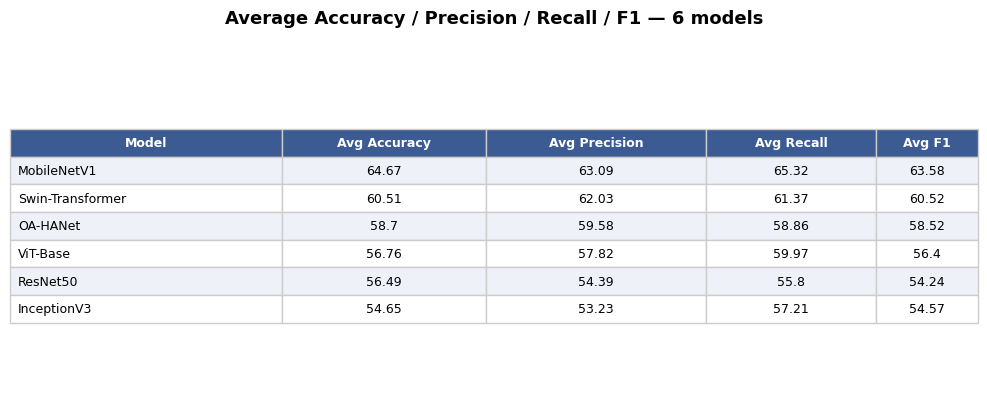

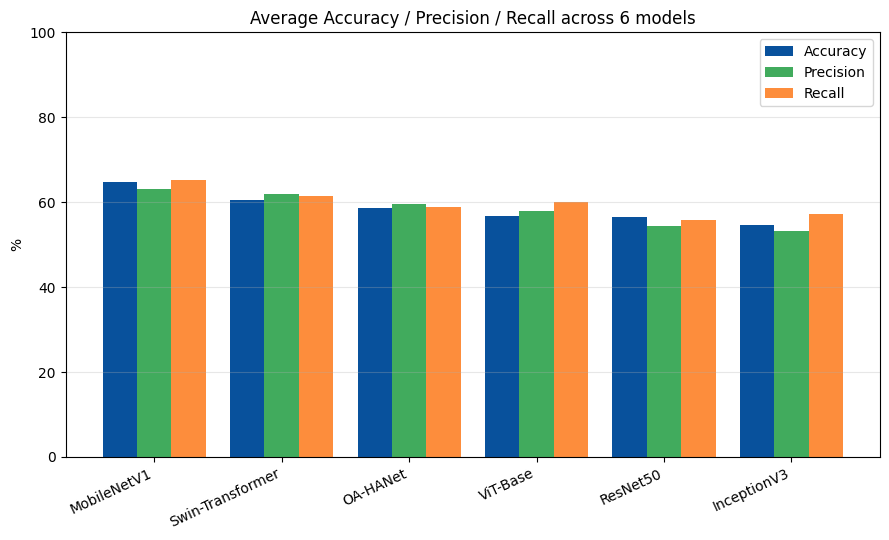

In [ ]:
cls_rows = []
for n in order:
    r = RESULTS[n]
    for ci in range(num_classes):
        cls_rows.append([n, f"{labels[ci]} ({class_short[ci]})",
                         round(r["per_class_precision"][ci]*100, 2),
                         round(r["per_class_recall"][ci]*100, 2),
                         round(r["per_class_f1"][ci]*100, 2)])
classwise_df = pd.DataFrame(cls_rows, columns=["Model", "KL Grade", "Precision", "Recall", "F1"])
classwise_df.to_csv(os.path.join(RESULTS_DIR, "table_classwise_metrics.csv"), index=False)
print(classwise_df.to_string(index=False))
render_df_table(classwise_df, "Classwise Precision / Recall / F1 — 6 models",
                "table_classwise_metrics.png", left_cols=("Model", "KL Grade"))

# recall heatmap (models x classes) — the clinically important metric
recall_mat = np.array([RESULTS[n]["per_class_recall"] for n in order]) * 100
fig, ax = plt.subplots(figsize=(8, 0.55*len(order)+2))
sns.heatmap(recall_mat, annot=True, fmt=".1f", cmap="YlGnBu",
            xticklabels=class_short, yticklabels=order, cbar_kws={"label": "Recall %"})
ax.set_title("Per-class Recall heatmap (models × KL grades)")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "heatmap_classwise_recall.png"),
                                dpi=160, bbox_inches="tight"); plt.show()

# average Accuracy / Precision / Recall / F1 summary + grouped bar chart
avg_rows = []
for n in order:
    r = RESULTS[n]
    avg_rows.append([n, round(r["test_acc"]*100,2), round(r["macro_precision"]*100,2),
                     round(r["macro_recall"]*100,2), round(r["macro_f1"]*100,2)])
avg_df = pd.DataFrame(avg_rows, columns=["Model","Avg Accuracy","Avg Precision","Avg Recall","Avg F1"]
                      ).sort_values("Avg Accuracy", ascending=False).reset_index(drop=True)
avg_df.to_csv(os.path.join(RESULTS_DIR, "table_avg_metrics.csv"), index=False)
print("\n", avg_df.to_string(index=False))
render_df_table(avg_df, "Average Accuracy / Precision / Recall / F1 — 6 models",
                "table_avg_metrics.png", left_cols=("Model",))

x = np.arange(len(avg_df)); w = 0.27
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(x-w, avg_df["Avg Accuracy"],  w, label="Accuracy",  color="#08519c")
ax.bar(x,   avg_df["Avg Precision"], w, label="Precision", color="#41ab5d")
ax.bar(x+w, avg_df["Avg Recall"],    w, label="Recall",    color="#fd8d3c")
ax.set_xticks(x); ax.set_xticklabels(avg_df["Model"], rotation=25, ha="right")
ax.set_ylabel("%"); ax.set_ylim(0, 100); ax.legend(); ax.grid(axis="y", alpha=0.3)
ax.set_title("Average Accuracy / Precision / Recall across 6 models")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "bar_avg_metrics.png"), dpi=160,
                                bbox_inches="tight"); plt.show()

## §14 · Misclassification analysis

For every model: the **top confusion pairs** (true grade → predicted grade, off-diagonal, sorted
by count) and a **gallery of misclassified test samples** with true/predicted grade and the
model's confidence in its (wrong) prediction — useful to spot systematic adjacent-grade errors vs.
severe mistakes.

           Model   True grade Predicted grade  Count  Grade distance
        ResNet50 Doubtful (1)      Normal (0)    309               1
        ResNet50     Mild (2)      Normal (0)    242               2
        ResNet50     Mild (2)    Doubtful (1)    203               1
        ResNet50   Normal (0)    Doubtful (1)    177               1
        ResNet50     Mild (2)    Moderate (3)    105               1
     InceptionV3   Normal (0)    Doubtful (1)    274               1
     InceptionV3 Doubtful (1)      Normal (0)    268               1
     InceptionV3     Mild (2)    Doubtful (1)    207               1
     InceptionV3     Mild (2)      Normal (0)    170               2
     InceptionV3     Mild (2)    Moderate (3)    142               1
     MobileNetV1 Doubtful (1)      Normal (0)    309               1
     MobileNetV1     Mild (2)      Normal (0)    167               2
     MobileNetV1     Mild (2)    Doubtful (1)    154               1
     MobileNetV1   Normal (0)    D

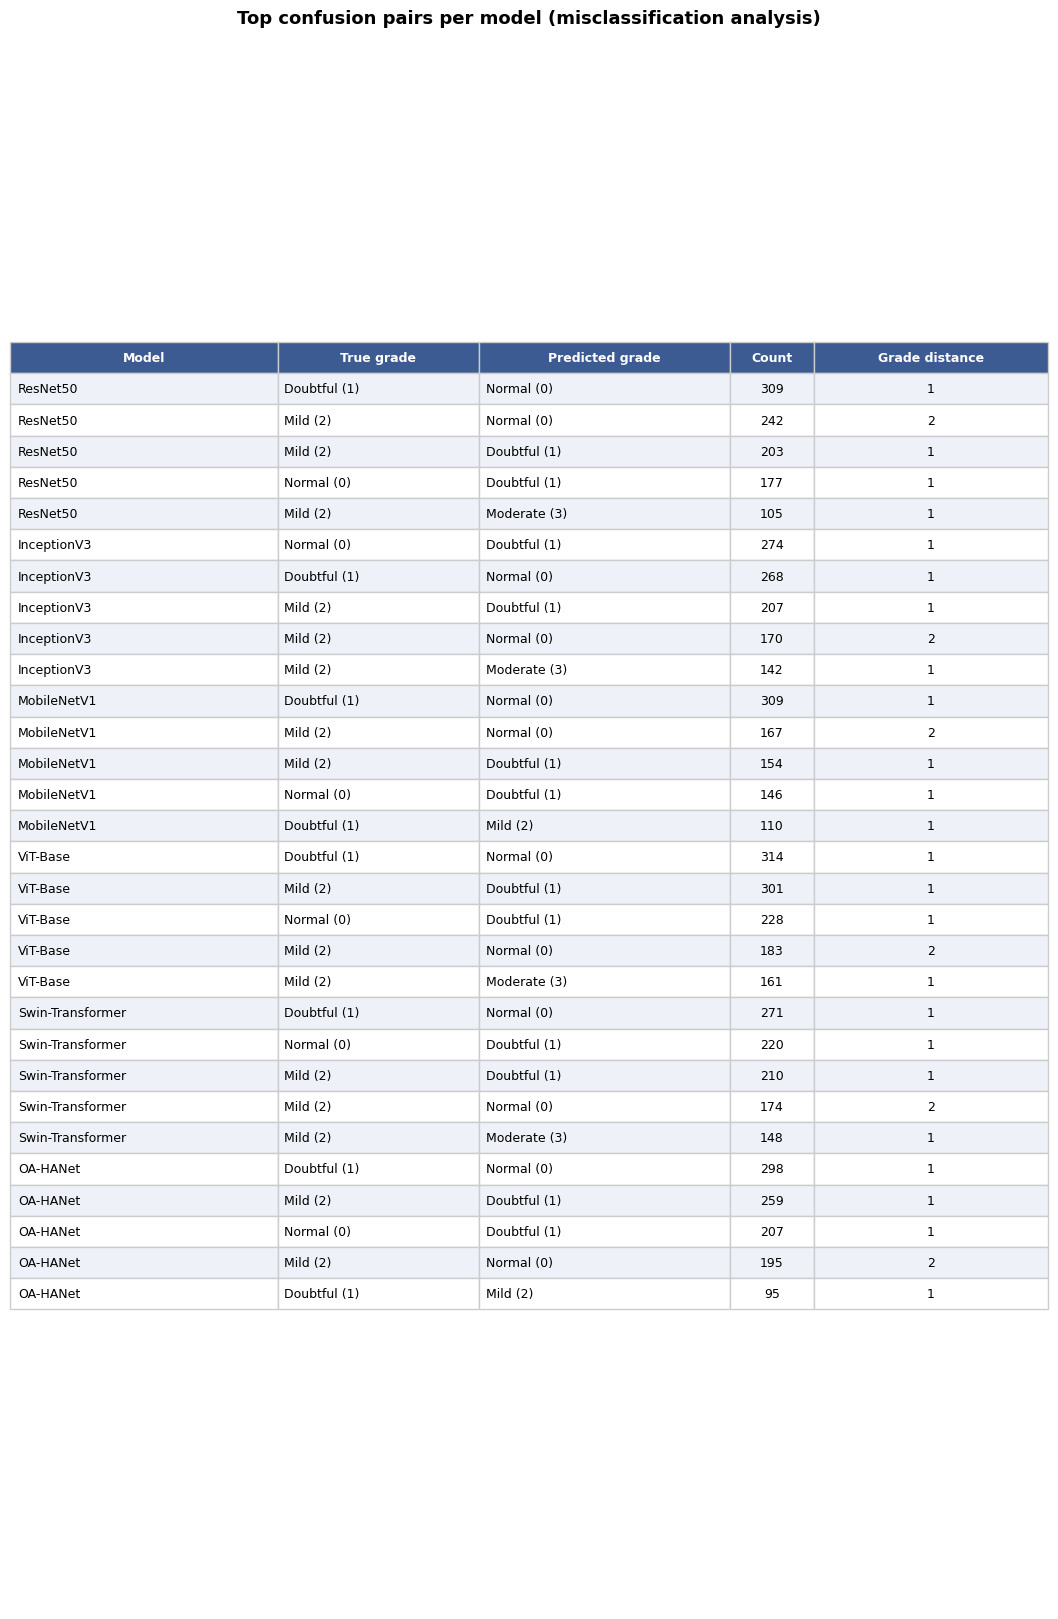

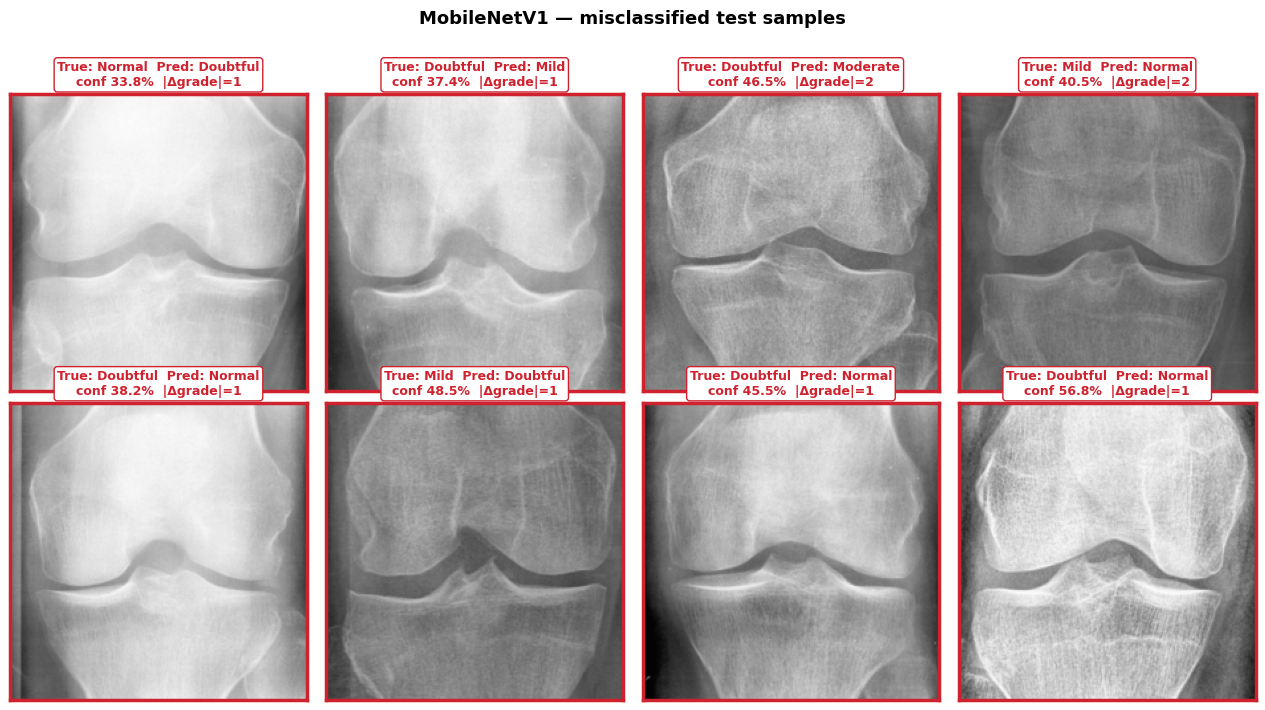

saved: /content/drive/MyDrive/OA_HANet_6_results/figures/misclassified_gallery_MobileNetV1.png


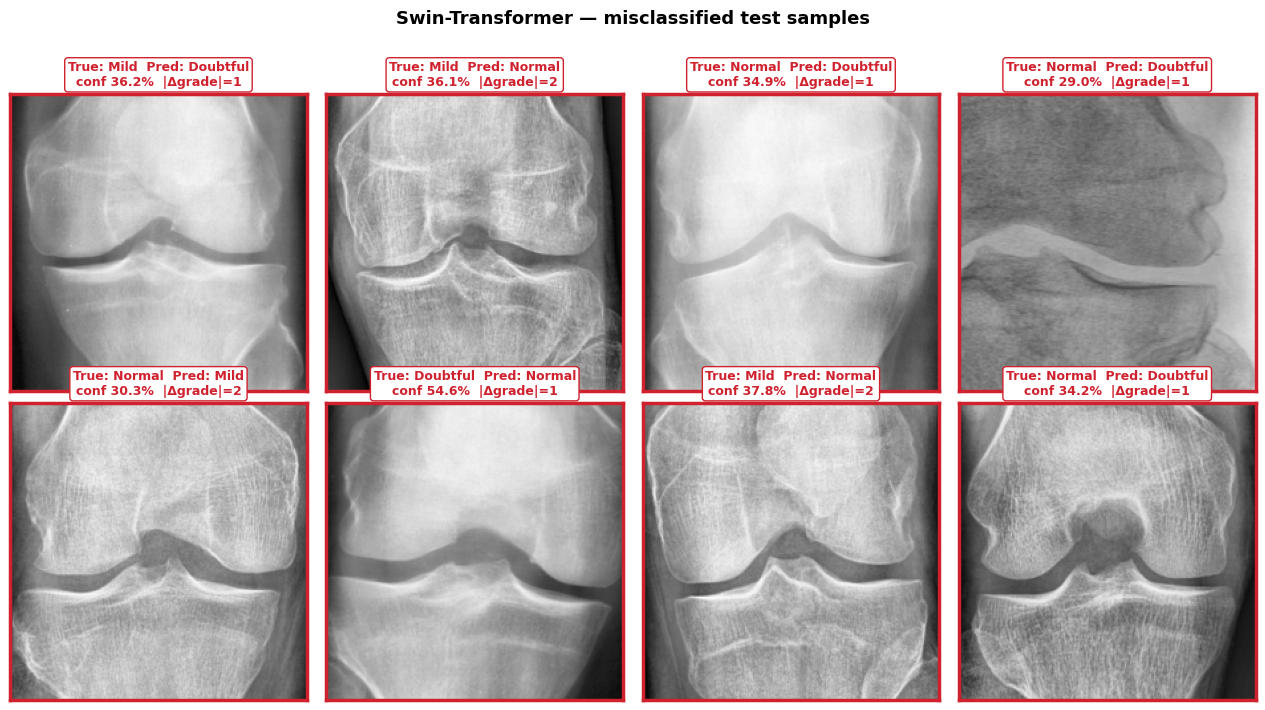

saved: /content/drive/MyDrive/OA_HANet_6_results/figures/misclassified_gallery_Swin-Transformer.png


In [ ]:
def confusion_pairs_table(name, top_k=8):
    r = RESULTS[name]
    cm = confusion_matrix(r["y_true"], r["y_pred"], labels=list(range(num_classes)))
    pairs = []
    for i in range(num_classes):
        for j in range(num_classes):
            if i != j and cm[i, j] > 0:
                pairs.append((i, j, int(cm[i, j])))
    pairs.sort(key=lambda t: t[2], reverse=True)
    rows = [[f"{class_short[i]} ({i})", f"{class_short[j]} ({j})", n, abs(i-j)]
            for i, j, n in pairs[:top_k]]
    return pd.DataFrame(rows, columns=["True grade", "Predicted grade", "Count", "Grade distance"])

misclass_rows = []
for n in order:
    top = confusion_pairs_table(n, top_k=5)
    for _, row in top.iterrows():
        misclass_rows.append([n, row["True grade"], row["Predicted grade"], row["Count"], row["Grade distance"]])
misclass_df = pd.DataFrame(misclass_rows, columns=["Model","True grade","Predicted grade","Count","Grade distance"])
misclass_df.to_csv(os.path.join(RESULTS_DIR, "table_top_confusion_pairs.csv"), index=False)
print(misclass_df.to_string(index=False))
render_df_table(misclass_df, "Top confusion pairs per model (misclassification analysis)",
                "table_top_confusion_pairs.png", left_cols=("Model","True grade","Predicted grade"))

def misclassified_gallery(name, n=8):
    r = RESULTS[name]
    yp, yt = np.array(r["y_pred"]), np.array(r["y_true"])
    ypr, paths, img_size = np.array(r["y_prob"]), r["paths"], r["img_size"]
    wrong = np.where(yp != yt)[0]
    if len(wrong) == 0:
        print(f"{name}: no misclassified test samples."); return
    idx = np.random.RandomState(SEED).choice(wrong, size=min(n, len(wrong)), replace=False)
    cols = min(4, len(idx)); rows_n = int(math.ceil(len(idx)/cols))
    fig, axes = plt.subplots(rows_n, cols, figsize=(3.2*cols, 3.6*rows_n)); axes = np.atleast_1d(axes).ravel()
    for k, i in enumerate(idx):
        img = load_image(paths[i], img_size, preprocess=True)
        conf = ypr[i][yp[i]] * 100
        dist = abs(int(yt[i]) - int(yp[i]))
        ax = axes[k]
        ax.imshow(img); ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"True: {class_short[yt[i]]}  Pred: {class_short[yp[i]]}\n"
                     f"conf {conf:.1f}%  |Δgrade|={dist}",
                     fontsize=9, color="#cf222e", fontweight="bold", pad=6,
                     bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#cf222e"))
        for s in ax.spines.values(): s.set_edgecolor("#cf222e"); s.set_linewidth(2.5)
    for j in range(len(idx), len(axes)): axes[j].axis("off")
    fig.suptitle(f"{name} — misclassified test samples", fontsize=13, fontweight="bold")
    plt.tight_layout(rect=[0,0,1,0.95])
    out = os.path.join(FIG_DIR, f"misclassified_gallery_{name}.png")
    plt.savefig(out, dpi=160, bbox_inches="tight"); plt.show(); print("saved:", out)

for n in BEST2:
    misclassified_gallery(n, n=8)

## §15 · Confidence-score sample collages

Best-2 models' predictions on 10 random test samples each, with the softmax confidence in the
predicted grade, green border = correct, red border = wrong.

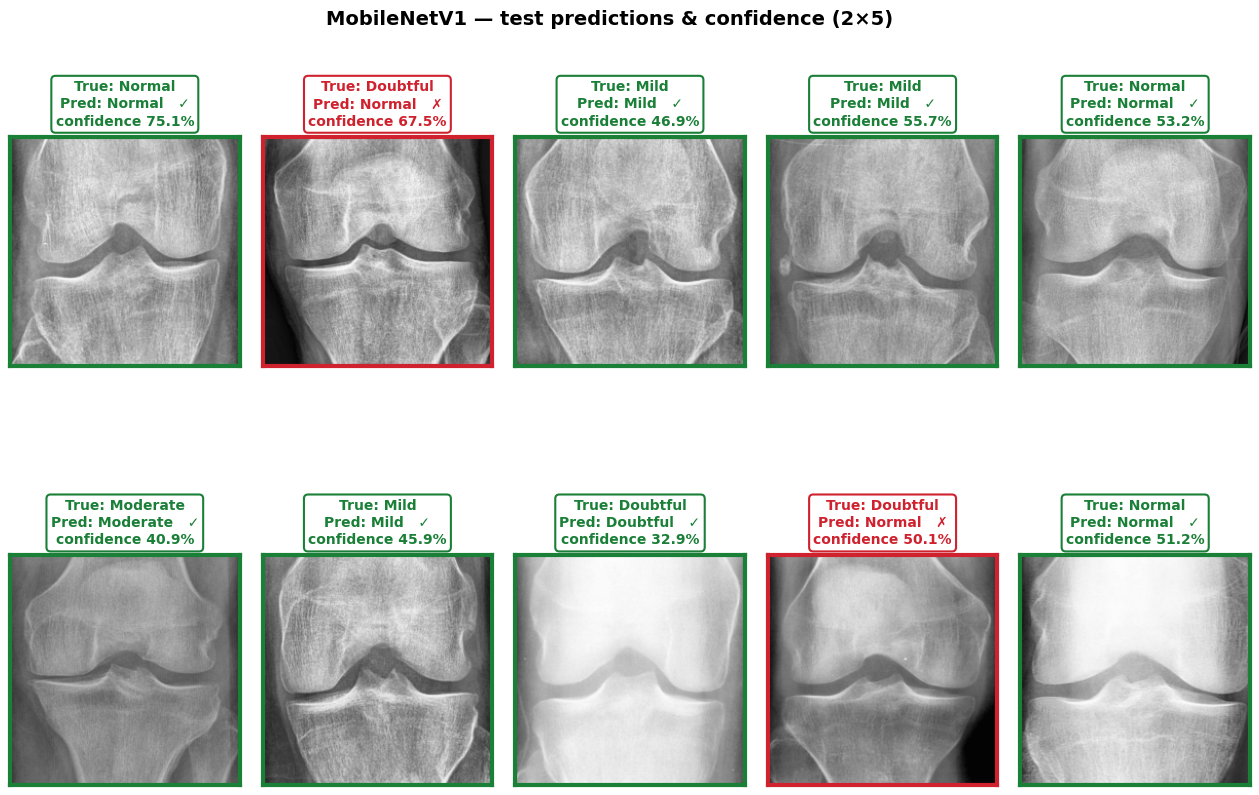

saved: /content/drive/MyDrive/OA_HANet_6_results/figures/confidence_collage_MobileNetV1.png


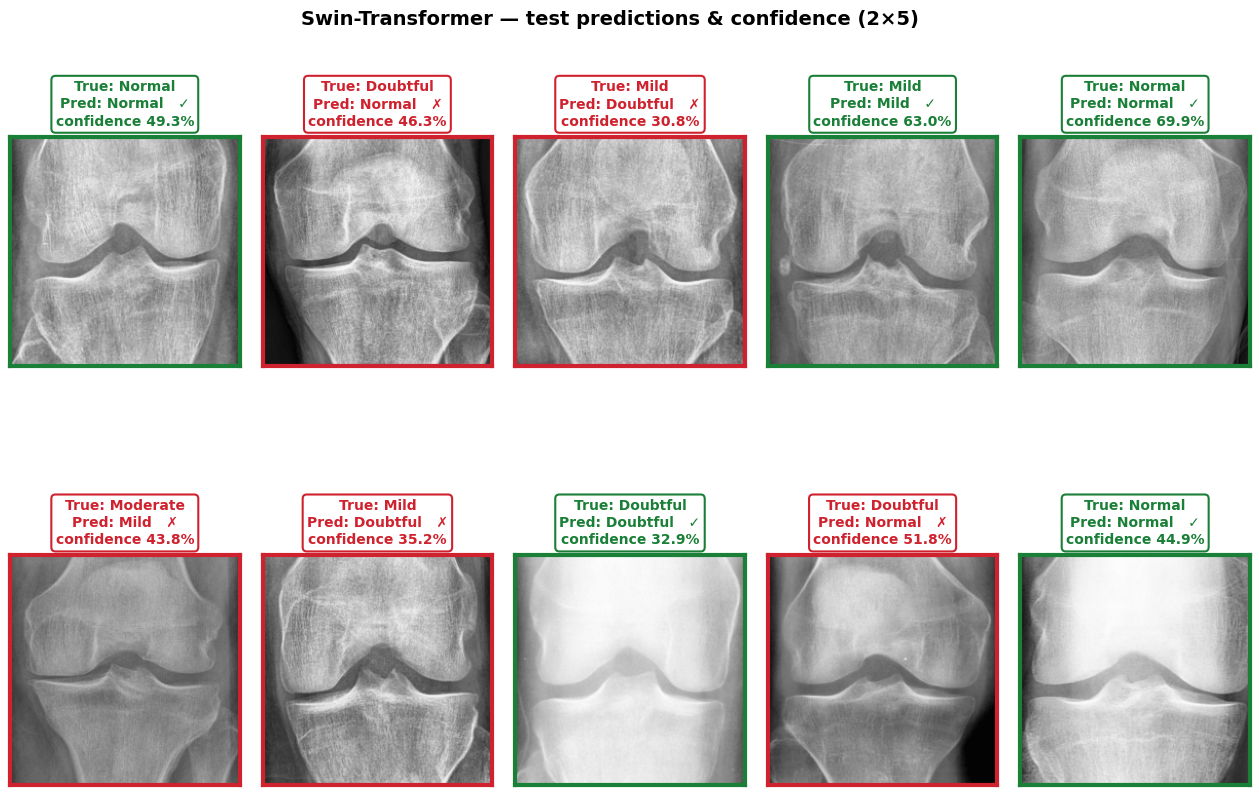

saved: /content/drive/MyDrive/OA_HANet_6_results/figures/confidence_collage_Swin-Transformer.png


In [ ]:
def confidence_collage(name, n=10):
    r = RESULTS[name]
    yp, yt, ypr = np.array(r["y_pred"]), np.array(r["y_true"]), np.array(r["y_prob"])
    paths, img_size = r["paths"], r["img_size"]
    idx = np.random.RandomState(SEED).choice(len(paths), size=min(n, len(paths)), replace=False)
    rows, cols = 2, 5
    fig, axes = plt.subplots(rows, cols, figsize=(3.2*cols, 4.1*rows)); axes = axes.ravel()
    for k, i in enumerate(idx):
        img = load_image(paths[i], img_size, preprocess=True)
        conf = ypr[i][yp[i]] * 100
        ok = bool(yp[i] == yt[i])
        col = "#1a7f37" if ok else "#cf222e"
        ax = axes[k]
        ax.imshow(img); ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"True: {class_short[yt[i]]}\nPred: {class_short[yp[i]]}   {'✓' if ok else '✗'}\n"
                     f"confidence {conf:.1f}%",
                     fontsize=10, color=col, fontweight="bold", linespacing=1.3, pad=8,
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=col, linewidth=1.5))
        for s in ax.spines.values(): s.set_edgecolor(col); s.set_linewidth(3)
    for j in range(len(idx), len(axes)): axes[j].axis("off")
    fig.suptitle(f"{name} — test predictions & confidence (2×5)", fontsize=14, fontweight="bold", y=0.99)
    plt.subplots_adjust(top=0.86, bottom=0.02, hspace=0.55, wspace=0.10)
    out = os.path.join(FIG_DIR, f"confidence_collage_{name}.png")
    plt.savefig(out, dpi=160, bbox_inches="tight"); plt.show(); print("saved:", out)

for n in BEST2:
    confidence_collage(n, n=10)

## §15B · Misclassification-error collages

Companion to the confidence collage: for each of the best-2 models, a 2×5 grid of its **most confident *wrong* predictions** on the test set (the most diagnostically informative errors). Each tile shows the true grade, the predicted grade, the model's (over-)confidence in the wrong prediction, and the grade distance `|Δ|`. Red border = misclassified.


In [ ]:
def misclassification_collage(name, n=10, mode="most_confident"):
    # 2x5 collage of misclassified TEST samples. mode="most_confident" surfaces the highest-confidence
    # mistakes (systematic errors worth inspecting); mode="random" draws a random sample of errors.
    r = RESULTS[name]
    yp, yt = np.array(r["y_pred"]), np.array(r["y_true"])
    ypr, paths, img_size = np.array(r["y_prob"]), r["paths"], r["img_size"]
    wrong = np.where(yp != yt)[0]
    if len(wrong) == 0:
        print(f"{name}: no misclassified test samples."); return
    if mode == "most_confident":
        conf_wrong = ypr[wrong, yp[wrong]]
        idx = wrong[np.argsort(-conf_wrong)][:n]
    else:
        idx = np.random.RandomState(SEED).choice(wrong, size=min(n, len(wrong)), replace=False)

    rows, cols = 2, 5
    fig, axes = plt.subplots(rows, cols, figsize=(3.2*cols, 4.1*rows)); axes = axes.ravel()
    for k, i in enumerate(idx):
        img  = load_image(paths[i], img_size, preprocess=True)
        conf = ypr[i][yp[i]] * 100
        dist = abs(int(yt[i]) - int(yp[i]))
        ax = axes[k]
        ax.imshow(img); ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"True: {class_short[yt[i]]}\nPred: {class_short[yp[i]]}   ✗\n"
                     f"confidence {conf:.1f}%   |Δ|={dist}",
                     fontsize=10, color="#cf222e", fontweight="bold", linespacing=1.3, pad=8,
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                               edgecolor="#cf222e", linewidth=1.5))
        for s in ax.spines.values(): s.set_edgecolor("#cf222e"); s.set_linewidth(3)
    for j in range(len(idx), len(axes)): axes[j].axis("off")
    fig.suptitle(f"{name} — most-confident misclassifications (2×5)",
                 fontsize=14, fontweight="bold", y=0.99)
    plt.subplots_adjust(top=0.86, bottom=0.02, hspace=0.55, wspace=0.10)
    out = os.path.join(FIG_DIR, f"misclassification_collage_{name}.png")
    plt.savefig(out, dpi=160, bbox_inches="tight"); plt.show(); print("saved:", out)

for n in BEST2:
    misclassification_collage(n, n=10, mode="most_confident")


## §16 · Grad-CAM explainability collages

For each of the two best models: one correctly-graded test sample per KL class, top row =
segmented radiograph, bottom row = Grad-CAM heat-map overlay. The target-layer picker hooks the
multi-scale CNN branch's last conv for OA-HANet, the final LayerNorm (with token→grid reshape) for
Swin/ViT, and the last Conv2d for plain CNNs.


Grad-CAM for MobileNetV1 (mobilenetv1_100.ra4_e3600_r224_in1k)
  loaded trained weights


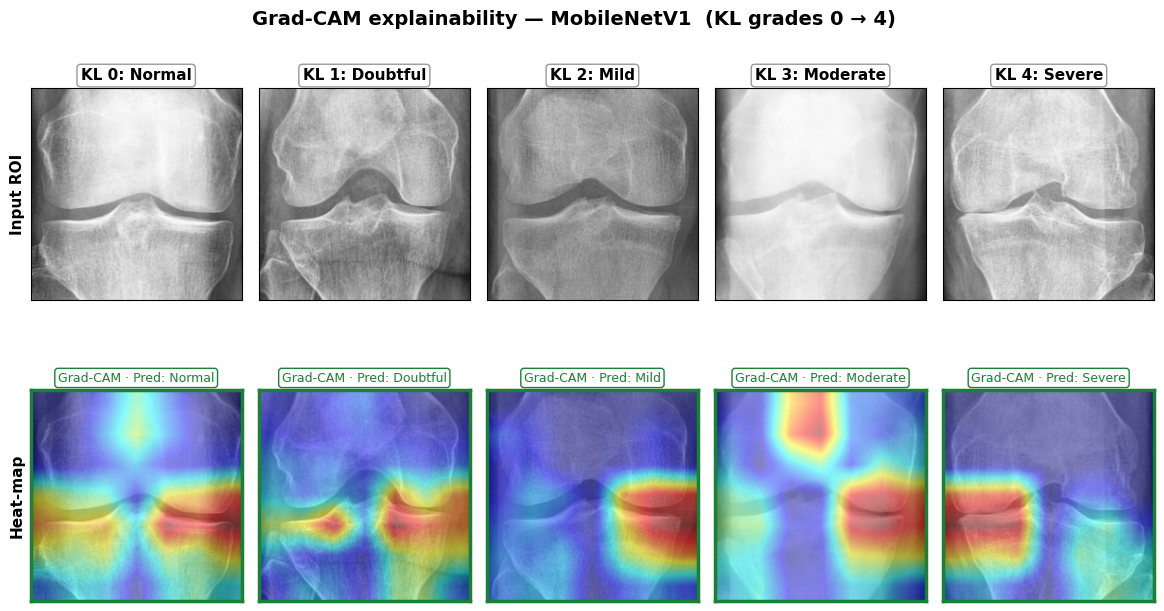

  saved: /content/drive/MyDrive/OA_HANet_6_results/figures/gradcam_collage_MobileNetV1.png

Grad-CAM for Swin-Transformer (swin_base_patch4_window7_224)
  loaded trained weights


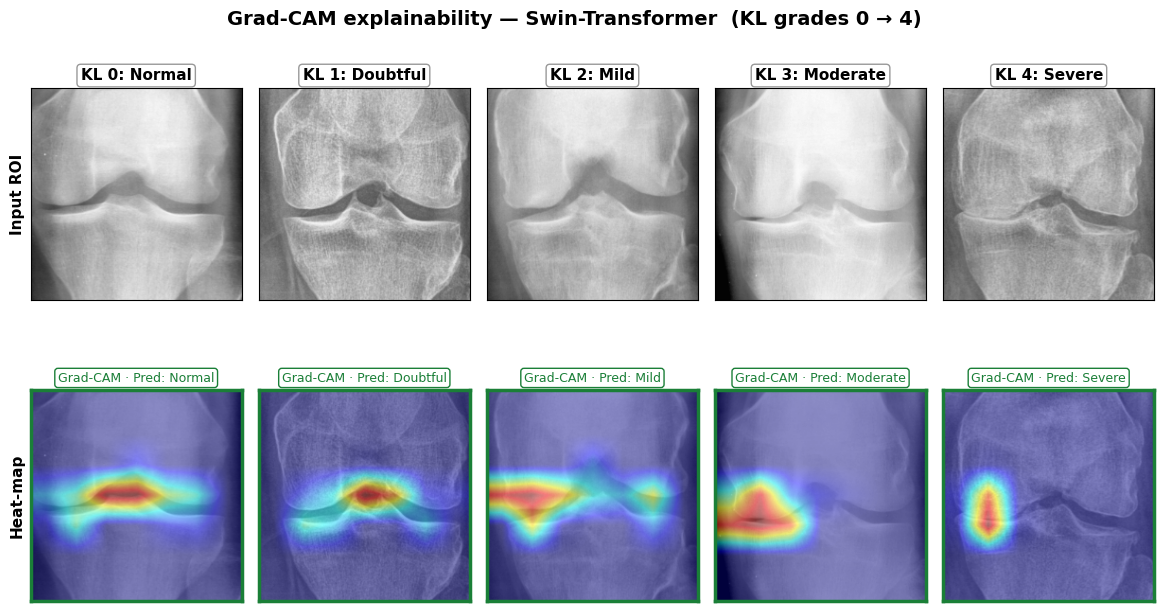

  saved: /content/drive/MyDrive/OA_HANet_6_results/figures/gradcam_collage_Swin-Transformer.png


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def _last_module(root, cls):
    found = None
    for m in root.modules():
        if isinstance(m, cls):
            found = m
    return found

def _cam_reshape(tensor):
    # token/sequence -> (B,C,H,W) for transformers; pass-through grids
    if tensor.dim() == 4:                      # (B,H,W,C) e.g. timm Swin
        return tensor.permute(0, 3, 1, 2)
    B, N, C = tensor.shape                      # (B,N,C) ViT (maybe +cls)
    h = w = int(round(N ** 0.5))
    if h * w != N:
        tensor = tensor[:, 1:, :]; N -= 1; h = w = int(round(N ** 0.5))
    return tensor.reshape(B, h, w, C).permute(0, 3, 1, 2)

def cam_config(model):
    nm = (getattr(model, "timm_name", "") or "").lower()
    if hasattr(model, "cnn"):                                   # OA-HANet multi-scale CNN branch
        conv = _last_module(model.cnn, nn.Conv2d)
        if conv is not None: return [conv], None
    if ("swin" in nm or "vit" in nm) or hasattr(model, "swin"):  # transformers
        bb = getattr(model, "swin", None) or getattr(model, "backbone", None)
        norm = _last_module(bb, nn.LayerNorm)
        if norm is not None: return [norm], _cam_reshape
    conv = _last_module(model, nn.Conv2d)
    return [conv], None

def _one_correct_path_per_class(res):
    yp, yt, paths = np.array(res["y_pred"]), np.array(res["y_true"]), res["paths"]
    chosen = {}
    rng = np.random.RandomState(SEED)
    for ci in range(num_classes):
        idx = np.where((yt == ci) & (yp == ci))[0]
        if len(idx) == 0:
            idx = np.where(yt == ci)[0]
        if len(idx):
            chosen[ci] = paths[int(rng.choice(idx))]
    return chosen

def gradcam_collage(name):
    res = RESULTS[name]
    img_size = res["img_size"]
    _, eval_tf = build_transforms(img_size)
    print(f"\nGrad-CAM for {name} ({res.get('timm_name','')})")
    model = MODEL_SPECS[name]["builder"]().to(device)
    wpath = os.path.join(CKPT_DIR, f"{name}.pt")
    if os.path.exists(wpath):
        model.load_state_dict(torch.load(wpath, map_location=device), strict=False)
        print("  loaded trained weights")
    else:
        print("  WARNING: trained weights not found — CAM uses pretrained-backbone features only")
    model.eval()
    target_layers, reshape = cam_config(model)
    if target_layers[0] is None:
        print("  no hookable layer found — skipped"); return
    chosen = _one_correct_path_per_class(res)
    cols = len(chosen)
    fig, axes = plt.subplots(2, cols, figsize=(2.9*cols, 6.2)); axes = np.atleast_2d(axes)
    try:
        cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape)
        for j, ci in enumerate(sorted(chosen)):
            path = chosen[ci]
            rgb = load_image(path, img_size, preprocess=True).astype(np.float32) / 255.0
            inp = eval_tf(load_image(path, img_size, preprocess=True)).unsqueeze(0).to(device)
            pred = int(model(inp).argmax(1).item())
            gcam = cam(input_tensor=inp, targets=[ClassifierOutputTarget(pred)],
                       aug_smooth=True, eigen_smooth=True)[0]
            gcam = cv2.GaussianBlur(gcam, (5, 5), 0)
            gcam = (gcam - gcam.min()) / (gcam.max() - gcam.min() + 1e-8)
            overlay = show_cam_on_image(rgb, gcam, use_rgb=True,
                                        colormap=cv2.COLORMAP_JET, image_weight=0.55)
            axes[0, j].imshow(rgb, cmap="gray"); axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
            axes[0, j].set_title(f"KL {ci}: {class_short[ci]}", fontsize=11, fontweight="bold", pad=6,
                                 bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6"))
            axes[1, j].imshow(overlay); axes[1, j].set_xticks([]); axes[1, j].set_yticks([])
            ok = (pred == ci)
            col = "#1a7f37" if ok else "#cf222e"
            axes[1, j].set_title(f"Grad-CAM · Pred: {class_short[pred]}", fontsize=9, color=col, pad=6,
                                 bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=col))
            for s in axes[1, j].spines.values(): s.set_edgecolor(col); s.set_linewidth(2.5)
        axes[0, 0].set_ylabel("Input ROI", fontsize=11, fontweight="bold")
        axes[1, 0].set_ylabel("Heat-map", fontsize=11, fontweight="bold")
        fig.suptitle(f"Grad-CAM explainability — {name}  (KL grades 0 → 4)",
                     fontsize=14, fontweight="bold", y=0.99)
        plt.subplots_adjust(top=0.88, bottom=0.02, hspace=0.30, wspace=0.08)
        out = os.path.join(FIG_DIR, f"gradcam_collage_{name}.png")
        plt.savefig(out, dpi=180, bbox_inches="tight"); plt.show(); print("  saved:", out)
    except Exception as e:
        plt.close(fig); print(f"  Grad-CAM failed for {name}: {type(e).__name__}: {e}")
    finally:
        del model; gc.collect(); torch.cuda.empty_cache() if device.type == "cuda" else None

for n in BEST2:
    gradcam_collage(n)

## §17 · Master results summary

           Model                                                                  Backbone  Img size Params Trainable  Latency (ms/img)  Train time (s)  Epochs
        ResNet50                                                                  resnet50       224  24.0M     15.5M              0.48          2138.1      62
     InceptionV3                                                              inception_v3       299  22.3M     12.2M              0.88          2251.0      44
     MobileNetV1                                       mobilenetv1_100.ra4_e3600_r224_in1k       224   3.5M      3.4M              0.23          1339.3      39
        ViT-Base                                                      vit_base_patch16_224       224  86.0M     23.8M              2.93          1225.1      36
Swin-Transformer                                              swin_base_patch4_window7_224       224  87.0M     30.7M              2.60          1548.2      45
        OA-HANet swin_base_patch4_window

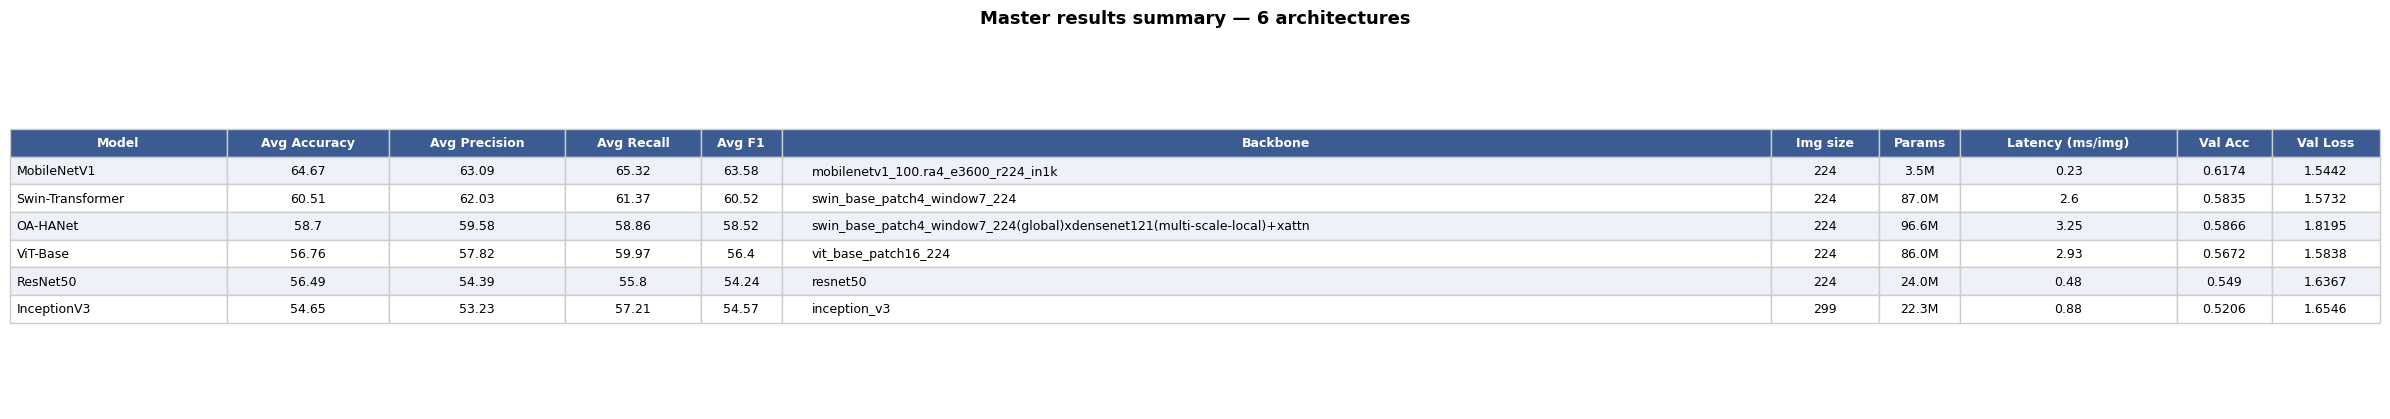


All tables/figures saved under: /content/drive/MyDrive/OA_HANet_6_results
Best 2 models: ['MobileNetV1', 'Swin-Transformer']


In [ ]:
tc_rows = []
for n in order:
    r = RESULTS[n]
    tc_rows.append([n, r.get("timm_name",""), r["img_size"], f"{r['params']/1e6:.1f}M",
                    f"{r['trainable_params']/1e6:.1f}M", round(r["latency_ms"],2),
                    round(r["train_time_s"],1), r["epochs_run"]])
tc_df = pd.DataFrame(tc_rows, columns=["Model","Backbone","Img size","Params","Trainable",
                                       "Latency (ms/img)","Train time (s)","Epochs"])
tc_df.to_csv(os.path.join(RESULTS_DIR, "table_time_complexity.csv"), index=False)
print(tc_df.to_string(index=False))

master = avg_df.merge(tc_df[["Model","Backbone","Img size","Params","Latency (ms/img)"]], on="Model", how="left")
master = master.merge(train_val_df[["Model","Val Acc","Val Loss"]], on="Model", how="left")
master.to_csv(os.path.join(RESULTS_DIR, "MASTER_summary.csv"), index=False)
print("\n", master.to_string(index=False))
render_df_table(master, "Master results summary — 6 architectures", "MASTER_summary.png",
                left_cols=("Model","Backbone"))
print("\nAll tables/figures saved under:", RESULTS_DIR)
print("Best 2 models:", BEST2)

## §18 · Push results to GitHub (optional)

Un-comment, set `GH_TOKEN` (Personal Access Token with Contents:write on the repo), and run to
push everything under `RESULTS_DIR` to `results/` on the target branch.

In [ ]:
# GH_TOKEN  = "ghp_xxxxxxxxxxxxxxxxxxxx"
# GH_REPO   = "poojanshah-code/oa_analysis"
# GH_BRANCH = "claude/knee-oa-classification-training-cym5m0"
# GH_EMAIL  = "poojan.shah@rru.ac.in"
# GH_NAME   = "Poojan Shah"
#
# import shutil
# !rm -rf /content/_oa_repo
# !git clone -b {GH_BRANCH} https://{GH_TOKEN}@github.com/{GH_REPO}.git /content/_oa_repo
# dst = "/content/_oa_repo/results/full_benchmark_6models"
# os.makedirs(dst, exist_ok=True)
# for f in glob.glob(os.path.join(RESULTS_DIR, "**", "*"), recursive=True):
#     if os.path.isfile(f):
#         rel = os.path.relpath(f, RESULTS_DIR)
#         os.makedirs(os.path.join(dst, os.path.dirname(rel)), exist_ok=True)
#         shutil.copy(f, os.path.join(dst, rel))
# %cd /content/_oa_repo
# !git config user.email "{GH_EMAIL}"
# !git config user.name  "{GH_NAME}"
# !git add results
# !git commit -m "Add 6-model KL-grading benchmark results (incl. OA-HANet)"
# !git push origin {GH_BRANCH}
print("Configure GH_TOKEN / GH_REPO / GH_BRANCH above and uncomment to push results to GitHub.")

Configure GH_TOKEN / GH_REPO / GH_BRANCH above and uncomment to push results to GitHub.


---
### Reproducibility checklist (v4 high-accuracy recipe)
1. **Default `QUICK_TEST=False`** → full paper-grade run (≤150 epochs, early stopping on
   balanced val-accuracy with patience 20, full data) — this produces the journal numbers.
2. Key levers vs. the old recipe: `FULL_FINETUNE=True` (whole backbone), layer-wise LR
   decay (`BACKBONE_LR=2e-4`, `LLRD_DECAY=0.70`, `HEAD_LR=1e-3`), `USE_SAMPLER=True`
   (balanced mini-batches), `USE_EMA=True`, `USE_TTA=True`, stronger augmentation.
3. To start a clean run, point `BASE_RESULTS_DIR` (§2) at a new folder before `Runtime → Run all`.
4. VRAM: `BATCH_SIZE=24` fits a 16 GB T4 for full fine-tuning; drop to 16 (or switch
   `SWIN_BACKBONE` to `swin_tiny_patch4_window7_224`) if OA-HANet OOMs.
5. (Optional) Flip `QUICK_TEST=True` first for a ~10-min smoke-test that all 6 models train
   and every figure/collage renders before committing to the full run.
